# AI-SDR: Intelligent Account Prioritization for Sales
## Complete Project Notebook — All Phases
**MS Data Science · DTSC 5082 · University of North Texas · Team 4**

---

### 👥 Team 4 — University of North Texas

| Member | Role | Key Contributions |
|--------|------|-------------------|
| 👩‍💻 Girivarshini Varatha Raja | Team Lead · XAI · Deployment | Data preprocessing, SHAP explainability, Streamlit app + RAG deployment |
| 👨‍💻 Kishore Dinakaran | ML Engineer · Model Development | Product-industry bridge, XGBoost tuning, API & monitoring design |
| 👩‍🔬 Praneetha Meda | Data Analyst · Validation | EDA visualizations, 5-fold CV, deployment documentation |
| 👨‍🔬 Vikram Batchu | Evaluation · RAG System | Ranking metrics P@K/NDCG, LIME explainability, RAG knowledge base |
---

### 📋 Notebook Structure

| Phase | Steps | Description |
|-------|-------|-------------|
| Phase 1 | 1–4 | Data Collection & Preprocessing |
| Phase 2 | 5–10 | Exploratory Data Analysis |
| Phase 3 | 11–21 | Model Development & Evaluation |
| Phase 4 | 22–25 | RAG Conversational System |
| Summary | 26 | Key Findings & Business Insights |

---

### 🎯 Project Goal
Given 1,000 real B2B companies and 9,994 real SaaS transactions,
rank the best companies to contact for each of 14 SaaS products —
and explain exactly why each company was ranked where it was.


---
# 📦 Phase 1: Data Collection & Preprocessing

## Step 1: Install & Import Libraries

In [1]:
!pip install xgboost lime shap pandas numpy matplotlib seaborn scikit-learn plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, precision_score,
    recall_score, f1_score, confusion_matrix
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
import shap
import lime
import lime.lime_tabular

plt.rcParams.update({
    'figure.figsize': (13, 6), 'axes.titlesize': 14,
    'axes.labelsize': 12, 'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_theme(style='whitegrid', palette='muted')

COLORS = {
    'primary'  : '#1C4E80',
    'secondary': '#0091D5',
    'accent'   : '#EA6A47',
    'green'    : '#2E8B57',
    'red'      : '#C0392B',
    'gold'     : '#F59E0B',
    'purple'   : '#7B2D8B',
}

print('✅ All libraries loaded')
print(f'   XGBoost : {__import__("xgboost").__version__}')
print(f'   SHAP    : {shap.__version__}')
print(f'   LIME    : loaded')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ All libraries loaded
   XGBoost : 3.2.0
   SHAP    : 0.51.0
   LIME    : loaded


## Step 2: Load Datasets

In [2]:
# Mount Google Drive if needed
# from google.colab import drive
# drive.mount('/content/drive')

df    = pd.read_csv('crunchbase_cleaned_enriched.csv')
df_ml = pd.read_csv('crunchbase_ml_ready.csv')
saas  = pd.read_csv('SaaS-Sales.csv')

print('=' * 60)
print(' DATASETS LOADED')
print('=' * 60)
print(f'  Crunchbase (enriched) : {df.shape[0]:,} companies × {df.shape[1]} features')
print(f'  Crunchbase (ML-ready) : {df_ml.shape[0]:,} companies × {df_ml.shape[1]} features')
print(f'  SaaS Sales            : {len(saas):,} transactions | {saas["Product"].nunique()} products | {saas["Industry"].nunique()} industries')
print()
print(f'  Conversion rate       : {df["converted"].mean()*100:.1f}%')
print(f'  Avg Lead Score        : {df["lead_score"].mean():.1f} / 100')
print(f'  Countries             : {df["country_code"].nunique()} unique')
print(f'  Industries            : {df["industry"].nunique()} unique')


 DATASETS LOADED
  Crunchbase (enriched) : 1,000 companies × 45 features
  Crunchbase (ML-ready) : 1,000 companies × 41 features
  SaaS Sales            : 9,994 transactions | 14 products | 10 industries

  Conversion rate       : 22.0%
  Avg Lead Score        : 34.4 / 100
  Countries             : 69 unique
  Industries            : 227 unique


## Step 3: Dataset Schema & Feature Categories

In [3]:
feature_map = {
    'Firmographic (12)' : ['name','country_code','region','city','industry',
                            'employee_range','employee_count_est','company_age_years',
                            'founded_year','ipo_status','is_active','is_for_profit'],
    'Funding (8)'       : ['has_funding','funding_total_usd','num_funding_rounds',
                            'last_funding_type','last_funding_year',
                            'fin_num_investors','num_investors','it_spend_usd'],
    'Digital (6)'       : ['active_tech_count','semrush_visits_latest_month',
                            'monthly_visits_growth','num_employee_profiles',
                            'cb_rank','web_visits_30d'],
    'CRM / Outreach (6)': ['num_contacts','days_since_last_contact',
                            'crm_completeness_pct','reply_rate_pct',
                            'email_engagement_score','active_hiring'],
    'Engineered (8)'    : ['lead_score','intent_score','deal_potential_usd',
                            'log_funding_total_usd','log_it_spend_usd',
                            'log_web_visits_30d','log_deal_potential_usd',
                            'recent_funding_event'],
    'Target (1)'        : ['converted'],
    'Encoded (4)'       : ['industry_enc','employee_range_enc',
                            'ipo_status_enc','region_enc'],
}

print('=' * 65)
print(' FEATURE SCHEMA')
print('=' * 65)
for cat, feats in feature_map.items():
    existing = [f for f in feats if f in df.columns]
    print(f'  {cat:<22} : {len(existing)} features')
    print(f'    {", ".join(existing[:5])}{"..." if len(existing)>5 else ""}')
print()
print(f'  Total features in enriched  : {df.shape[1]}')
print(f'  Total features in ML-ready  : {df_ml.shape[1]}')


 FEATURE SCHEMA
  Firmographic (12)      : 12 features
    name, country_code, region, city, industry...
  Funding (8)            : 8 features
    has_funding, funding_total_usd, num_funding_rounds, last_funding_type, last_funding_year...
  Digital (6)            : 6 features
    active_tech_count, semrush_visits_latest_month, monthly_visits_growth, num_employee_profiles, cb_rank...
  CRM / Outreach (6)     : 6 features
    num_contacts, days_since_last_contact, crm_completeness_pct, reply_rate_pct, email_engagement_score...
  Engineered (8)         : 4 features
    lead_score, intent_score, deal_potential_usd, recent_funding_event
  Target (1)             : 1 features
    converted
  Encoded (4)            : 0 features
    

  Total features in enriched  : 45
  Total features in ML-ready  : 41


## Step 4: Preprocessing Pipeline

In [4]:
print('PREPROCESSING STEPS APPLIED TO CRUNCHBASE RAW DATA')
print('=' * 65)
steps = [
    ('1. Column Reduction',  '92 raw cols → 45 features (dropped null, redundant, internal IDs)'),
    ('2. JSON Parsing',      'Parsed: industries[], funding_rounds{}, financials{}, it_spend{}'),
    ('3. Excel Date Fix',    '"10-Jan"→"1-10" (Excel column mangling in num_employees)'),
    ('4. Date Parsing',      'founded_date → founded_year + company_age_years'),
    ('5. Missing Values',    'Numeric: median | Categorical: "Unknown" | Counts: 0'),
    ('6. Log Transforms',    'log1p() on: funding, it_spend, web_visits, deal_potential'),
    ('7. Outlier Handling',  'monthly_visits_growth clipped [-5,+5]'),
    ('8. Label Encoding',    'industry, employee_range, ipo_status, region → numeric'),
    ('9. Feature Creation',  'lead_score, intent_score, deal_potential_usd engineered'),
    ('10. Target Variable',  'converted: binary 0/1 (22% positive rate)'),
]
for step, desc in steps:
    print(f'  {step:<22} → {desc}')

print()

# Missing values check
missing = df.isnull().sum()
print(f'Missing values after preprocessing: {missing[missing>0].sum()} total')
if missing[missing>0].sum() == 0:
    print('✅ No missing values — preprocessing complete')


PREPROCESSING STEPS APPLIED TO CRUNCHBASE RAW DATA
  1. Column Reduction    → 92 raw cols → 45 features (dropped null, redundant, internal IDs)
  2. JSON Parsing        → Parsed: industries[], funding_rounds{}, financials{}, it_spend{}
  3. Excel Date Fix      → "10-Jan"→"1-10" (Excel column mangling in num_employees)
  4. Date Parsing        → founded_date → founded_year + company_age_years
  5. Missing Values      → Numeric: median | Categorical: "Unknown" | Counts: 0
  6. Log Transforms      → log1p() on: funding, it_spend, web_visits, deal_potential
  7. Outlier Handling    → monthly_visits_growth clipped [-5,+5]
  8. Label Encoding      → industry, employee_range, ipo_status, region → numeric
  9. Feature Creation    → lead_score, intent_score, deal_potential_usd engineered
  10. Target Variable    → converted: binary 0/1 (22% positive rate)

Missing values after preprocessing: 1903 total


---
# 📊 Phase 2: Exploratory Data Analysis

## Step 5: Descriptive Statistics & Key Business Metrics

In [5]:
print('KEY BUSINESS METRICS')
print('=' * 55)
metrics = {
    'Total Companies'          : f'{len(df):,}',
    'Conversion Rate'          : f'{df["converted"].mean()*100:.1f}%',
    'Avg Lead Score'           : f'{df["lead_score"].mean():.1f} / 100',
    'Median Lead Score'        : f'{df["lead_score"].median():.1f} / 100',
    'Has Funding (%)'          : f'{df["has_funding"].mean()*100:.1f}%',
    'Recent Funding Event (%)' : f'{df["recent_funding_event"].mean()*100:.1f}%',
    'Actively Hiring (%)'      : f'{df["active_hiring"].mean()*100:.1f}%',
    'Avg Intent Score'         : f'{df["intent_score"].mean():.1f} / 100',
    'Avg Email Engagement'     : f'{df["email_engagement_score"].mean():.1f} / 100',
    'Avg CRM Completeness'     : f'{df["crm_completeness_pct"].mean():.1f}%',
    'Countries'                : f'{df["country_code"].nunique()}',
    'Industries'               : f'{df["industry"].nunique()}',
}
for k, v in metrics.items():
    print(f'  {k:<30} : {v}')

# Descriptive stats table
stat_cols = ['lead_score','intent_score','email_engagement_score',
             'reply_rate_pct','crm_completeness_pct','active_tech_count',
             'company_age_years','funding_total_usd','deal_potential_usd']
stat_cols = [c for c in stat_cols if c in df.columns]
stats = df[stat_cols].describe().T
stats['median']   = df[stat_cols].median()
stats['skewness'] = df[stat_cols].skew()
print()
print('Descriptive Statistics:')
display(stats[['mean','median','std','min','25%','75%','max','skewness']].round(2))


KEY BUSINESS METRICS
  Total Companies                : 1,000
  Conversion Rate                : 22.0%
  Avg Lead Score                 : 34.4 / 100
  Median Lead Score              : 29.9 / 100
  Has Funding (%)                : 11.8%
  Recent Funding Event (%)       : 11.4%
  Actively Hiring (%)            : 36.4%
  Avg Intent Score               : 40.7 / 100
  Avg Email Engagement           : 27.4 / 100
  Avg CRM Completeness           : 45.2%
  Countries                      : 69
  Industries                     : 227

Descriptive Statistics:


,mean,median,std,min,25%,75%,max,skewness
lead_score,34.36,29.89,13.07,12.99,24.07,41.86,8.326000e+01,1.09
intent_score,40.67,39.60,16.24,4.30,28.60,50.20,9.670000e+01,0.49
email_engagement_score,27.40,26.45,13.36,0.00,18.50,36.50,7.340000e+01,0.39
reply_rate_pct,10.53,8.97,8.50,0.00,3.88,15.61,4.274000e+01,0.88
crm_completeness_pct,45.24,44.10,10.71,20.00,38.30,50.00,9.440000e+01,1.22
active_tech_count,11.48,7.00,13.81,0.00,5.00,12.00,1.540000e+02,3.69
company_age_years,16.08,14.00,9.87,0.00,10.00,20.00,4.800000e+01,1.11
funding_total_usd,4460376.16,0.00,68142365.67,0.00,0.00,0.00,1.830000e+09,23.15
deal_potential_usd,166207.64,27093.00,860920.01,2884.00,19927.00,48102.75,1.000000e+07,8.95


## Step 6: Visualization 1 — Lead Score Distribution

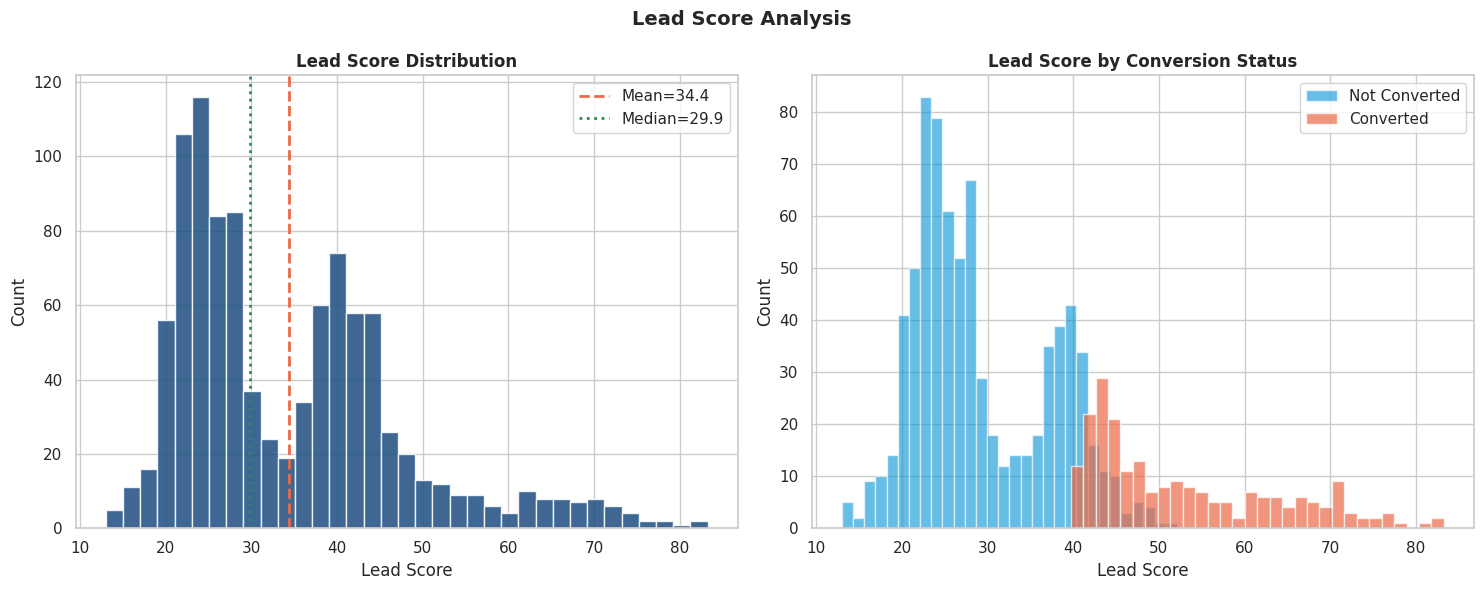

Converted companies avg score    : 52.8
Non-converted companies avg score: 29.2


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].hist(df['lead_score'], bins=35, color=COLORS['primary'],
             edgecolor='white', alpha=0.85)
axes[0].axvline(df['lead_score'].mean(), color=COLORS['accent'],
                lw=2, linestyle='--', label=f'Mean={df["lead_score"].mean():.1f}')
axes[0].axvline(df['lead_score'].median(), color=COLORS['green'],
                lw=2, linestyle=':', label=f'Median={df["lead_score"].median():.1f}')
axes[0].set_xlabel('Lead Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Lead Score Distribution', fontweight='bold')
axes[0].legend()

converted_scores   = df[df['converted']==1]['lead_score']
unconverted_scores = df[df['converted']==0]['lead_score']
axes[1].hist(unconverted_scores, bins=30, alpha=0.6,
             color=COLORS['secondary'], label='Not Converted', edgecolor='white')
axes[1].hist(converted_scores, bins=30, alpha=0.7,
             color=COLORS['accent'], label='Converted', edgecolor='white')
axes[1].set_xlabel('Lead Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Lead Score by Conversion Status', fontweight='bold')
axes[1].legend()

plt.suptitle('Lead Score Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_viz1_lead_score.png', bbox_inches='tight')
plt.show()

print(f'Converted companies avg score    : {converted_scores.mean():.1f}')
print(f'Non-converted companies avg score: {unconverted_scores.mean():.1f}')


## Step 7: Visualization 2 — Conversion Rates by Segment

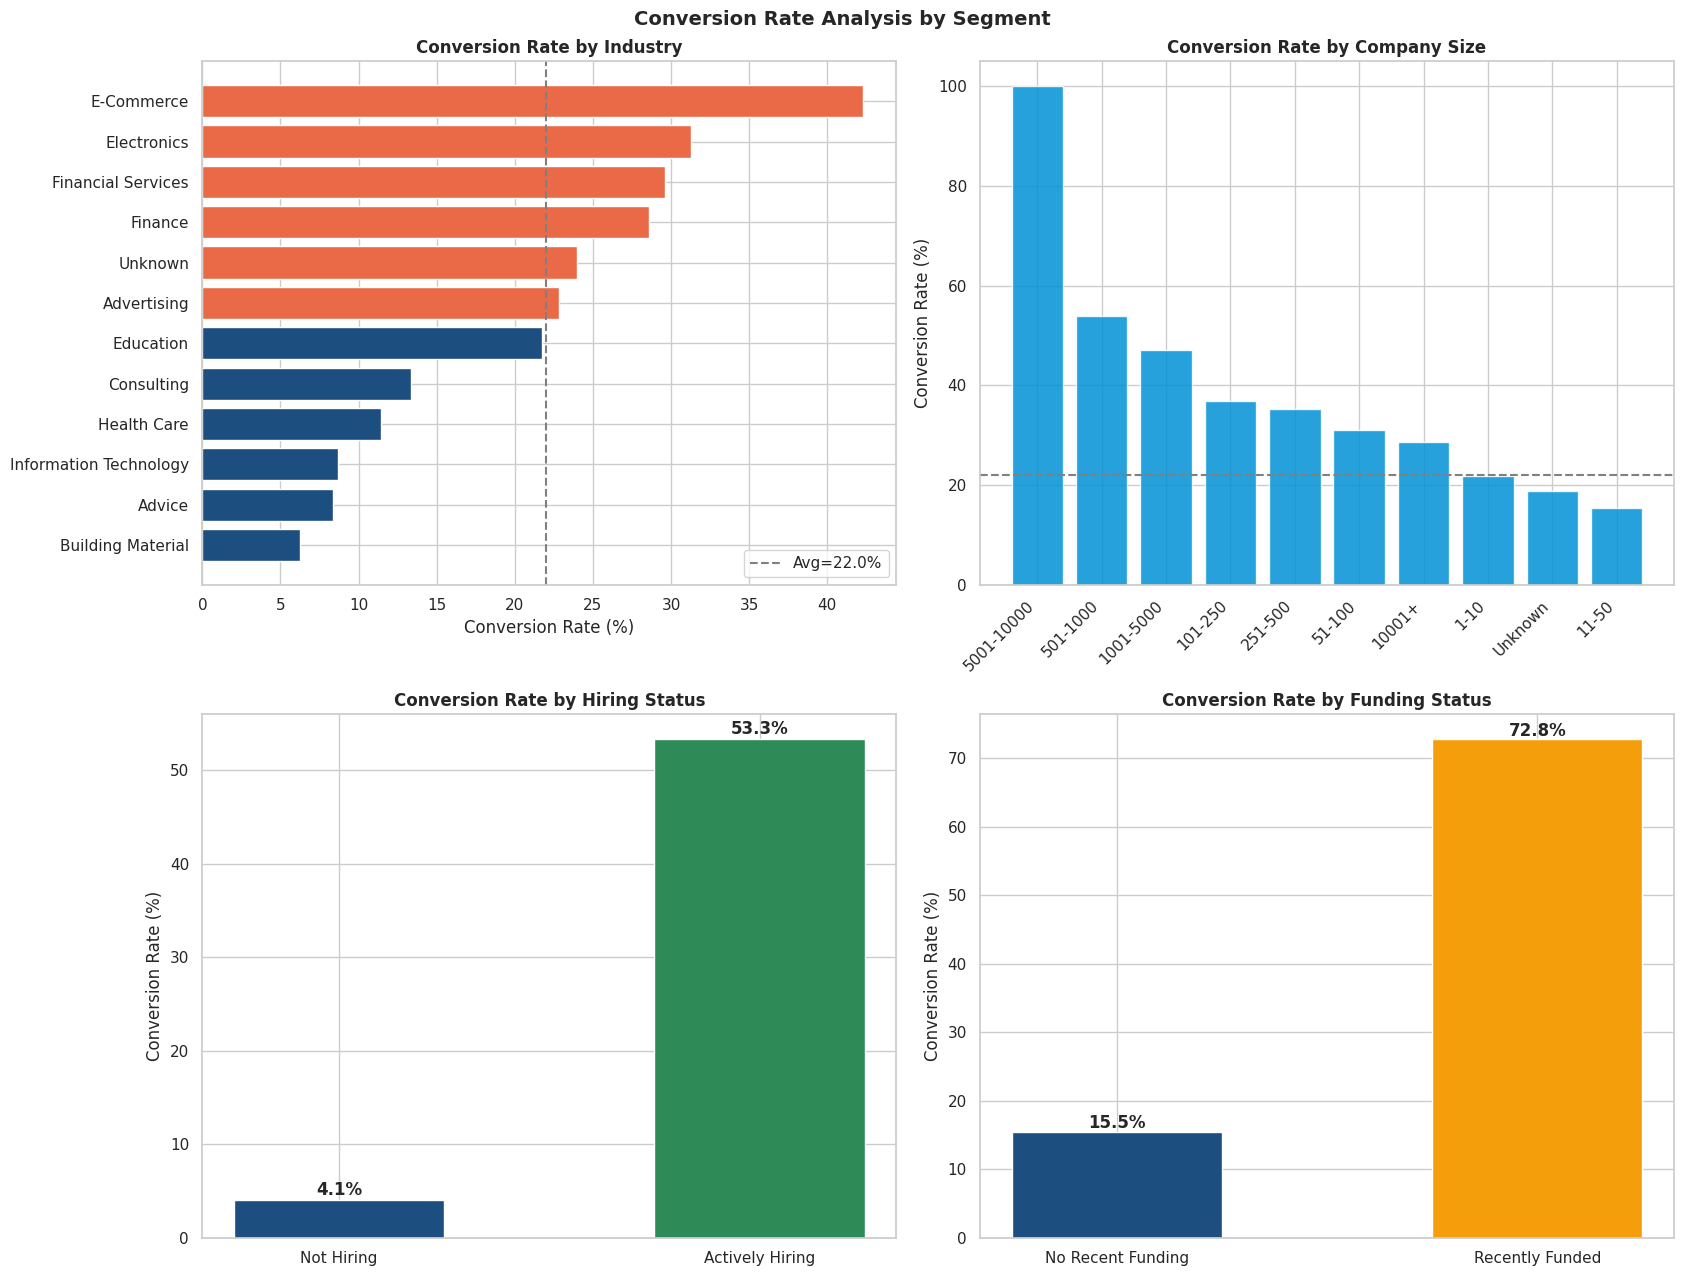

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(17, 13))
avg_conv = df['converted'].mean() * 100

# By industry
top_inds = df['industry'].value_counts().head(12).index
ind_conv = df[df['industry'].isin(top_inds)].groupby('industry')['converted'].mean()*100
ind_conv = ind_conv.sort_values(ascending=False)
colors_ind = [COLORS['accent'] if v > avg_conv else COLORS['primary']
              for v in ind_conv.values]
axes[0,0].barh(ind_conv.index[::-1], ind_conv.values[::-1],
               color=colors_ind[::-1], edgecolor='white')
axes[0,0].axvline(avg_conv, color='gray', linestyle='--', lw=1.5,
                  label=f'Avg={avg_conv:.1f}%')
axes[0,0].set_xlabel('Conversion Rate (%)')
axes[0,0].set_title('Conversion Rate by Industry', fontweight='bold')
axes[0,0].legend()

# By employee range
emp_conv = df.groupby('employee_range')['converted'].mean()*100
emp_conv = emp_conv.sort_values(ascending=False)
axes[0,1].bar(range(len(emp_conv)), emp_conv.values,
              color=COLORS['secondary'], edgecolor='white', alpha=0.85)
axes[0,1].set_xticks(range(len(emp_conv)))
axes[0,1].set_xticklabels(emp_conv.index, rotation=45, ha='right')
axes[0,1].axhline(avg_conv, color='gray', linestyle='--', lw=1.5)
axes[0,1].set_ylabel('Conversion Rate (%)')
axes[0,1].set_title('Conversion Rate by Company Size', fontweight='bold')

# By hiring status
hiring_conv = df.groupby('active_hiring')['converted'].mean()*100
labels = ['Not Hiring', 'Actively Hiring']
colors_h = [COLORS['primary'], COLORS['green']]
bars = axes[1,0].bar(labels, hiring_conv.values, color=colors_h,
                      edgecolor='white', width=0.5)
for bar, val in zip(bars, hiring_conv.values):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, val+0.5,
                   f'{val:.1f}%', ha='center', fontweight='bold')
axes[1,0].set_ylabel('Conversion Rate (%)')
axes[1,0].set_title('Conversion Rate by Hiring Status', fontweight='bold')

# By funding status
fund_conv = df.groupby('recent_funding_event')['converted'].mean()*100
labels_f = ['No Recent Funding', 'Recently Funded']
bars_f = axes[1,1].bar(labels_f, fund_conv.values,
                        color=[COLORS['primary'], COLORS['gold']],
                        edgecolor='white', width=0.5)
for bar, val in zip(bars_f, fund_conv.values):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, val+0.5,
                   f'{val:.1f}%', ha='center', fontweight='bold')
axes[1,1].set_ylabel('Conversion Rate (%)')
axes[1,1].set_title('Conversion Rate by Funding Status', fontweight='bold')

plt.suptitle('Conversion Rate Analysis by Segment',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_viz2_conversion.png', bbox_inches='tight')
plt.show()


## Step 8: Visualization 3 — Feature Correlation Heatmap

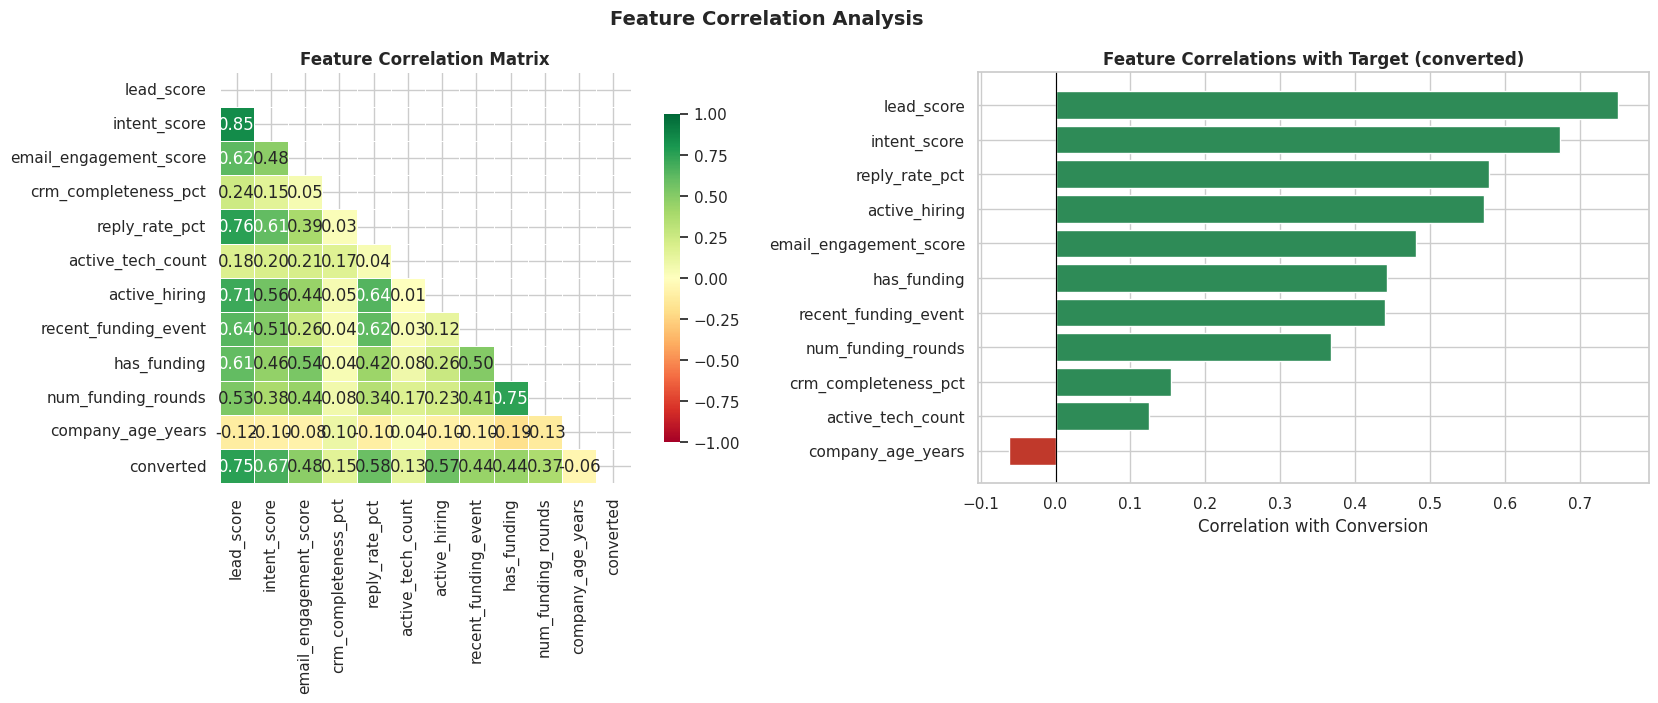

Top 5 positive correlations with conversion:
lead_score                0.7504
intent_score              0.6734
reply_rate_pct            0.5783
active_hiring             0.5716
email_engagement_score    0.4807


In [8]:
heatmap_cols = ['lead_score','intent_score','email_engagement_score',
               'crm_completeness_pct','reply_rate_pct','active_tech_count',
               'active_hiring','recent_funding_event','has_funding',
               'num_funding_rounds','company_age_years','converted']
heatmap_cols = [c for c in heatmap_cols if c in df.columns]

corr = df[heatmap_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Full heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=axes[0], square=True,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Feature Correlation Matrix', fontweight='bold')

# Top correlations with converted
corr_target = corr['converted'].drop('converted').sort_values()
colors_corr = [COLORS['red'] if v < 0 else COLORS['green']
               for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values,
             color=colors_corr, edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Correlation with Conversion')
axes[1].set_title('Feature Correlations with Target (converted)',
                  fontweight='bold')

plt.suptitle('Feature Correlation Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_viz3_correlation.png', bbox_inches='tight')
plt.show()

print('Top 5 positive correlations with conversion:')
print(corr_target.sort_values(ascending=False).head(5).round(4).to_string())


## Step 9: Visualization 4 — Engagement Signals vs Lead Score

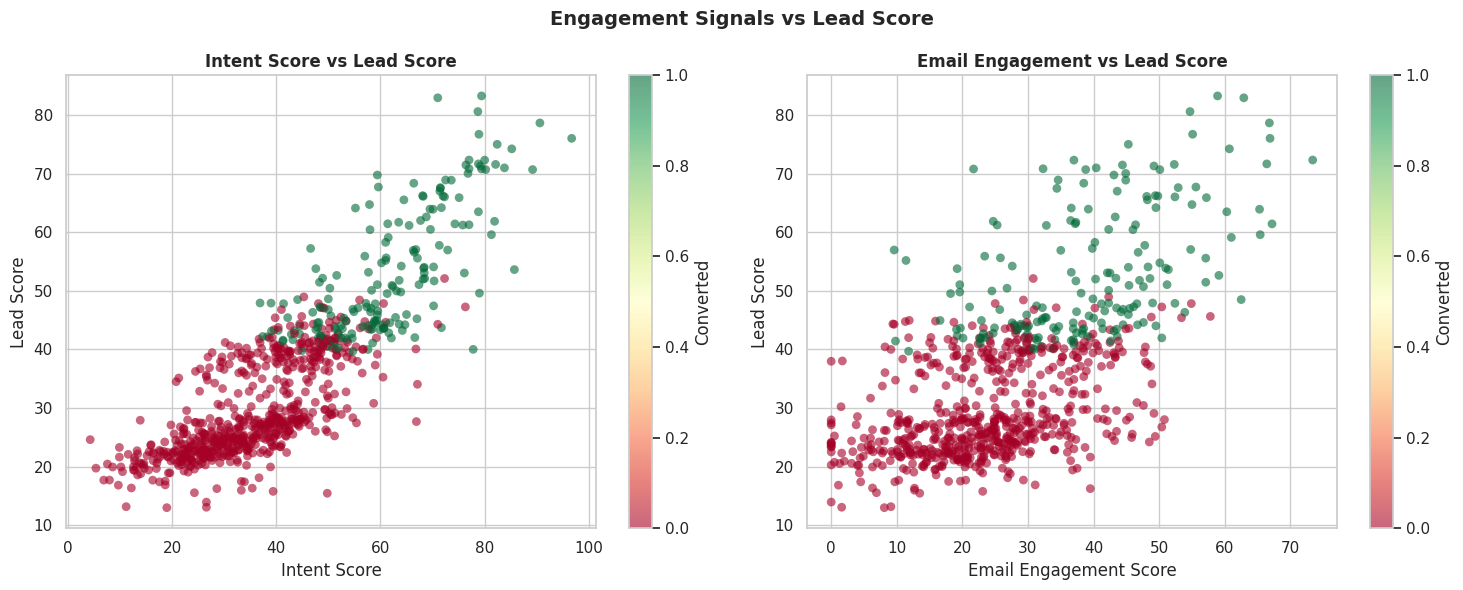

Intent Score vs Lead Score correlation      : r = 0.8459
Email Engagement vs Lead Score correlation  : r = 0.6200


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sample = df.sample(min(800, len(df)), random_state=42)

# Scatter 1
sc1 = axes[0].scatter(
    sample['intent_score'], sample['lead_score'],
    c=sample['converted'], cmap='RdYlGn',
    alpha=0.6, s=40, edgecolors='none'
)
axes[0].set_xlabel('Intent Score')
axes[0].set_ylabel('Lead Score')
axes[0].set_title('Intent Score vs Lead Score', fontweight='bold')
plt.colorbar(sc1, ax=axes[0], label='Converted')

# Scatter 2
sc2 = axes[1].scatter(
    sample['email_engagement_score'], sample['lead_score'],
    c=sample['converted'], cmap='RdYlGn',
    alpha=0.6, s=40, edgecolors='none'
)
axes[1].set_xlabel('Email Engagement Score')
axes[1].set_ylabel('Lead Score')
axes[1].set_title('Email Engagement vs Lead Score', fontweight='bold')
plt.colorbar(sc2, ax=axes[1], label='Converted')

plt.suptitle('Engagement Signals vs Lead Score',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_viz4_scatter.png', bbox_inches='tight')
plt.show()

# Correlation values
r1 = df['intent_score'].corr(df['lead_score'])
r2 = df['email_engagement_score'].corr(df['lead_score'])
print(f'Intent Score vs Lead Score correlation      : r = {r1:.4f}')
print(f'Email Engagement vs Lead Score correlation  : r = {r2:.4f}')


## Step 10: Visualization 5 — Product-Industry Affinity Matrix

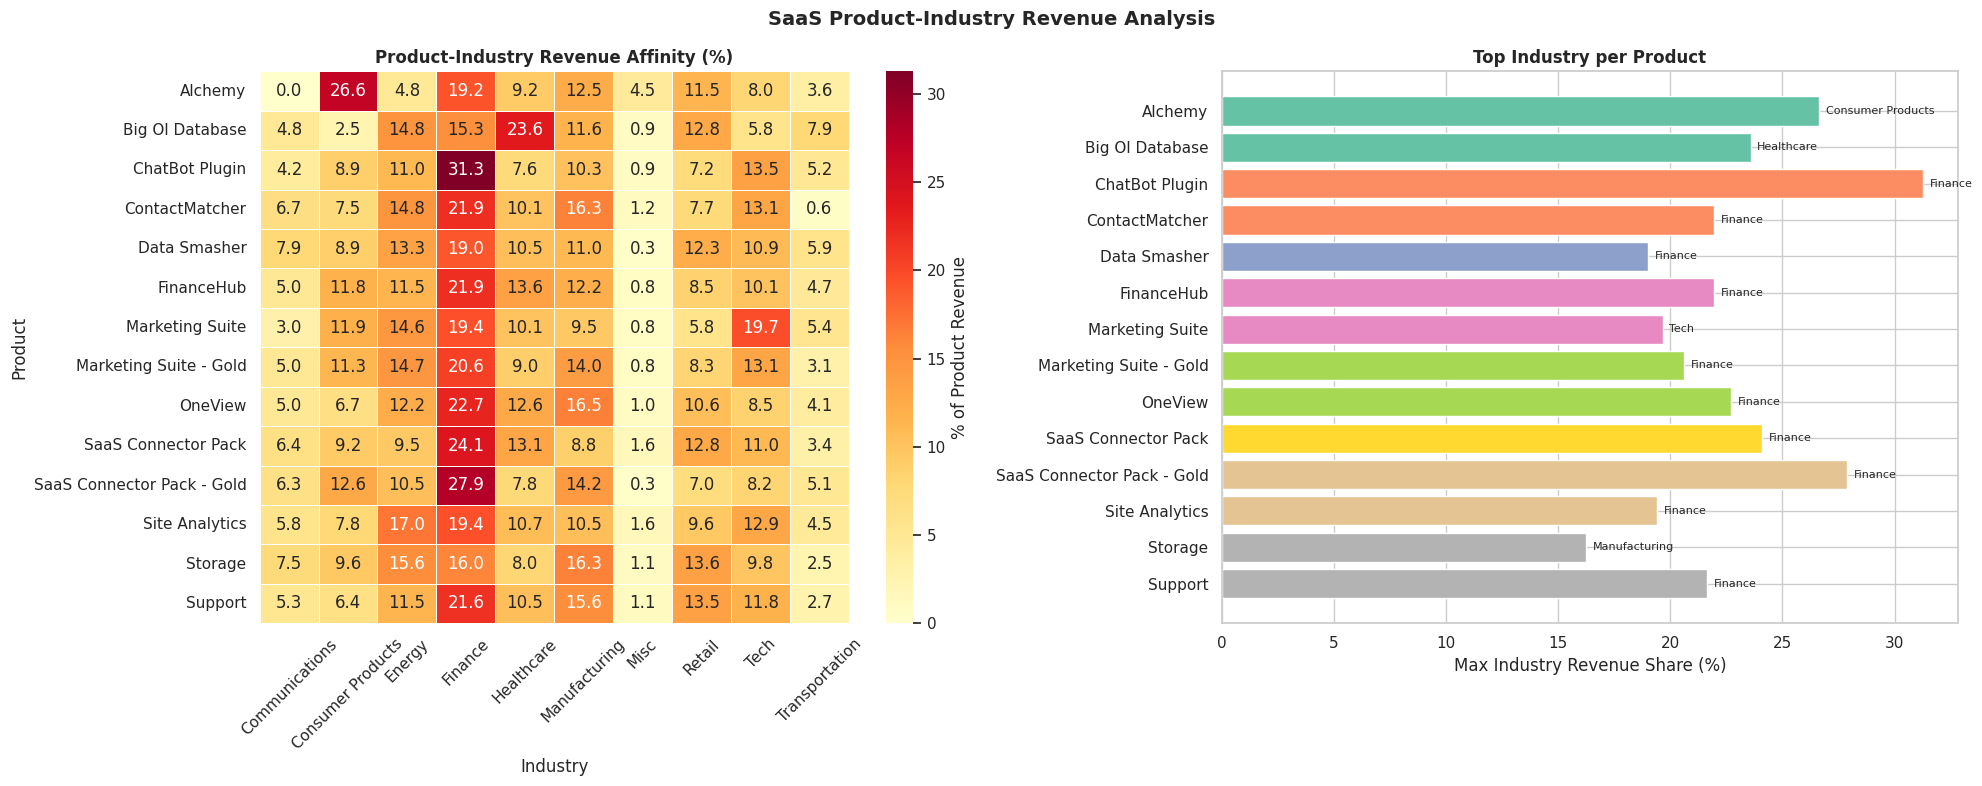

Top buying industry per product:
  Alchemy                        → Consumer Products (26.6%)
  Big Ol Database                → Healthcare (23.6%)
  ChatBot Plugin                 → Finance (31.3%)
  ContactMatcher                 → Finance (21.9%)
  Data Smasher                   → Finance (19.0%)
  FinanceHub                     → Finance (21.9%)
  Marketing Suite                → Tech (19.7%)
  Marketing Suite - Gold         → Finance (20.6%)
  OneView                        → Finance (22.7%)
  SaaS Connector Pack            → Finance (24.1%)
  SaaS Connector Pack - Gold     → Finance (27.9%)
  Site Analytics                 → Finance (19.4%)
  Storage                        → Manufacturing (16.3%)
  Support                        → Finance (21.6%)


In [10]:
# Revenue by product and industry
pivot = saas.groupby(['Product','Industry'])['Sales'].sum().unstack().fillna(0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Revenue heatmap
sns.heatmap(pivot_pct, annot=True, fmt='.1f',
            cmap='YlOrRd', linewidths=0.5,
            ax=axes[0], cbar_kws={'label': '% of Product Revenue'})
axes[0].set_title('Product-Industry Revenue Affinity (%)',
                  fontweight='bold')
axes[0].set_xlabel('Industry')
axes[0].set_ylabel('Product')
axes[0].tick_params(axis='x', rotation=45)

# Top industry per product
top_ind = pivot_pct.idxmax(axis=1)
top_val = pivot_pct.max(axis=1)
colors_p = plt.cm.Set2(np.linspace(0, 1, len(top_ind)))
axes[1].barh(top_ind.index[::-1], top_val.values[::-1],
             color=colors_p[::-1], edgecolor='white')
for bar, (prod, ind) in zip(axes[1].patches,
                             zip(top_ind.index[::-1], top_ind.values[::-1])):
    axes[1].text(bar.get_width()+0.3,
                 bar.get_y()+bar.get_height()/2,
                 ind, va='center', fontsize=8)
axes[1].set_xlabel('Max Industry Revenue Share (%)')
axes[1].set_title('Top Industry per Product', fontweight='bold')

plt.suptitle('SaaS Product-Industry Revenue Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_viz5_product_industry.png', bbox_inches='tight')
plt.show()

print('Top buying industry per product:')
for prod in top_ind.index:
    print(f'  {prod:<30} → {top_ind[prod]} ({top_val[prod]:.1f}%)')


---
# 🤖 Phase 3: Model Development & Evaluation

## Step 11: Build Product-Specific Labels from Real Transaction Data

In [11]:
SAAS_TO_CB = {
    'Finance'          : ['Financial Services','Banking','Insurance',
                          'Investment Management','Finance','Accounting','Payments'],
    'Tech'             : ['Information Technology','Software','Internet','SaaS',
                          'Artificial Intelligence','Apps','Analytics'],
    'Healthcare'       : ['Health Care','Biotechnology','Medical Devices',
                          'Pharmaceuticals','Dental'],
    'Manufacturing'    : ['Manufacturing','Automotive','Electronics',
                          'Industrial','Aerospace','Building Material','Construction'],
    'Retail'           : ['Retail','E-Commerce','Consumer Goods',
                          'Food and Beverage','Grocery'],
    'Energy'           : ['Oil, Gas and Mining','Utilities','Energy',
                          'Environmental Services','Biofuel'],
    'Consumer Products': ['Consumer Goods','Food and Beverage',
                          'Personal Care','Cosmetics'],
    'Communications'   : ['Telecommunications','Media and Entertainment',
                          'Broadcasting','Publishing'],
    'Transportation'   : ['Transportation','Logistics and Supply Chain',
                          'Airlines and Aviation','Delivery'],
    'Misc'             : ['Consulting','Advertising','Professional Services',
                          'Marketing','Digital Marketing','Advice',
                          'Business Development','Education','EdTech'],
}

def build_product_labels(product_name, df_enriched, saas,
                          revenue_threshold=0.60):
    prod_data  = saas[saas['Product'] == product_name]
    ind_rev    = prod_data.groupby('Industry')['Sales'].sum().sort_values(ascending=False)
    cumulative = (ind_rev / ind_rev.sum()).cumsum()
    top_saas   = set(cumulative[cumulative <= revenue_threshold].index)
    if len(top_saas) < 2:
        top_saas = set(ind_rev.head(2).index)
    top_cb = set()
    for si in top_saas:
        for ci in SAAS_TO_CB.get(si, []):
            top_cb.add(ci)
    return df_enriched['industry'].apply(lambda x: 1 if x in top_cb else 0), top_saas

print('=' * 65)
print(' PRODUCT-SPECIFIC LABELS (from real transaction data)')
print('=' * 65)
print(f'{"Product":<30} {"Top Industries":<28} {"Positive%"}')
print('-' * 65)

product_labels = {}
for prod in sorted(saas['Product'].unique()):
    labels, top_saas = build_product_labels(prod, df, saas)
    product_labels[prod] = labels
    top_str = ', '.join(list(top_saas)[:2])
    print(f'{prod:<30} {top_str:<28} {labels.mean()*100:.1f}%')


 PRODUCT-SPECIFIC LABELS (from real transaction data)
Product                        Top Industries               Positive%
-----------------------------------------------------------------
Alchemy                        Consumer Products, Finance   18.6%
Big Ol Database                Finance, Energy              14.5%
ChatBot Plugin                 Finance, Energy              16.5%
ContactMatcher                 Finance, Energy              17.4%
Data Smasher                   Finance, Energy              22.6%
FinanceHub                     Consumer Products, Finance   24.5%
Marketing Suite                Finance, Energy              16.5%
Marketing Suite - Gold         Finance, Energy              17.4%
OneView                        Finance, Healthcare          22.1%
SaaS Connector Pack            Retail, Finance              18.5%
SaaS Connector Pack - Gold     Consumer Products, Finance   18.6%
Site Analytics                 Finance, Energy              16.5%
Storage           

## Step 12: Feature Selection — Three Methods

Product  : ContactMatcher
Positive : 17.4% (174 companies)
Features : 21



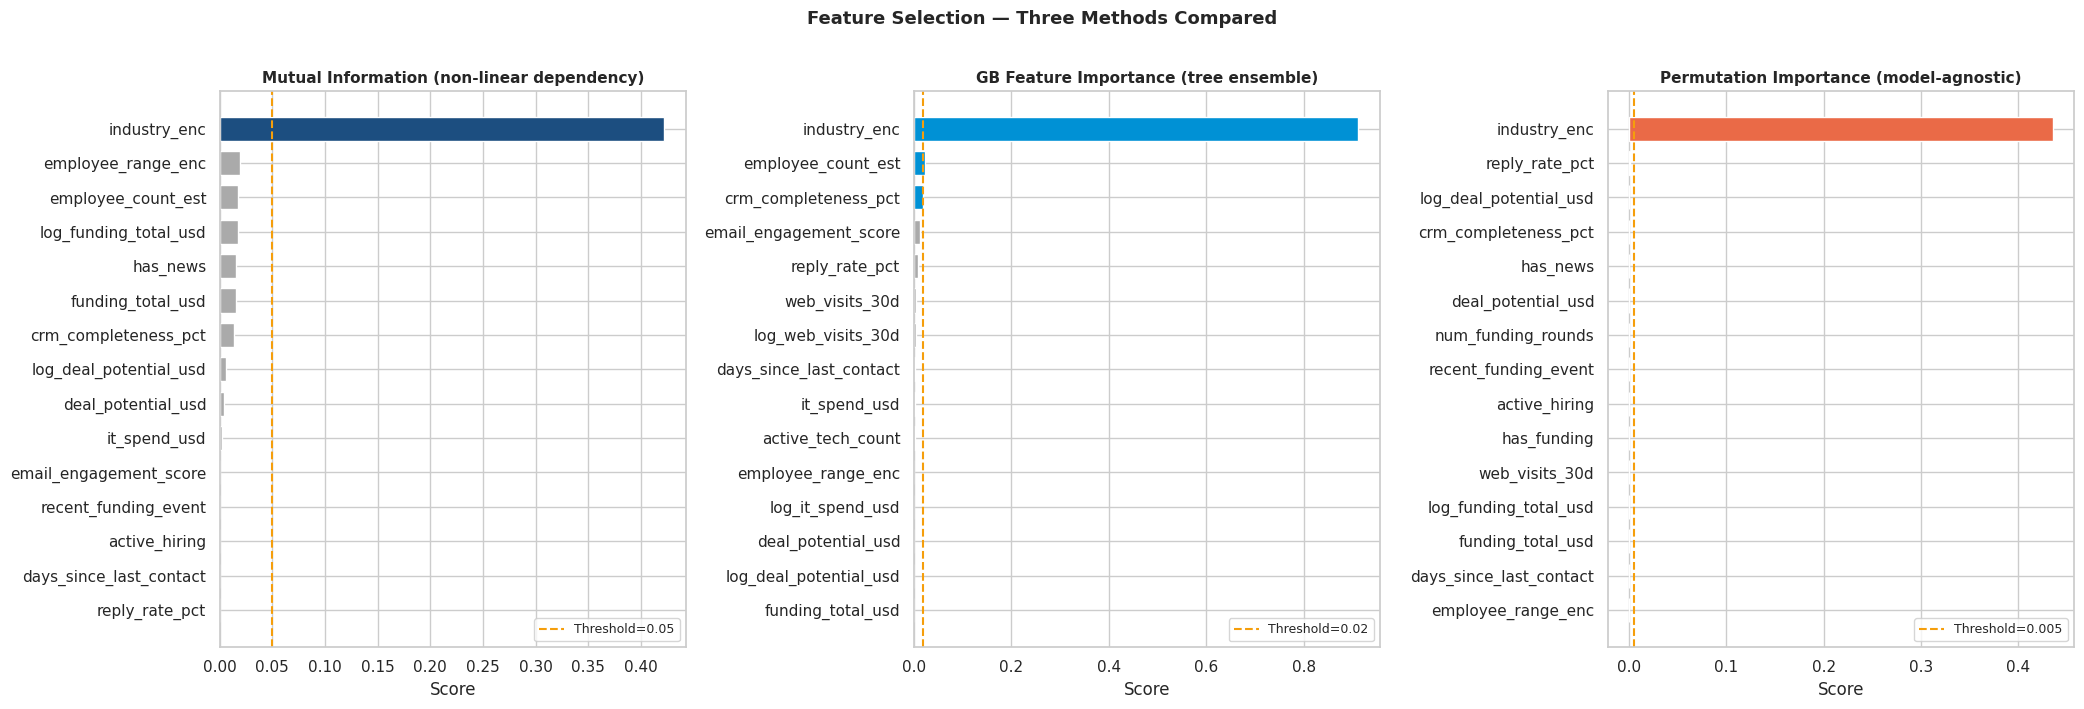

Top 5 features (Mutual Information):
industry_enc             0.4215
employee_range_enc       0.0198
employee_count_est       0.0173
log_funding_total_usd    0.0171
has_news                 0.0158


In [12]:
SELECTED_PRODUCT = 'ContactMatcher'

FEATURE_COLS = [
    'active_hiring','recent_funding_event','reply_rate_pct',
    'email_engagement_score','days_since_last_contact',
    'log_web_visits_30d','web_visits_30d','crm_completeness_pct',
    'active_tech_count','has_news','has_funding',
    'funding_total_usd','log_funding_total_usd','num_funding_rounds',
    'it_spend_usd','log_it_spend_usd','employee_count_est',
    'industry_enc','employee_range_enc',
    'deal_potential_usd','log_deal_potential_usd',
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_ml.columns]

X     = df_ml[FEATURE_COLS].copy()
y_cls = product_labels[SELECTED_PRODUCT].copy()

X_train, X_test, yc_tr, yc_te = train_test_split(
    X, y_cls, test_size=0.20, random_state=42, stratify=y_cls
)
scaler = StandardScaler()
Xs_tr  = scaler.fit_transform(X_train)
Xs_te  = scaler.transform(X_test)

print(f'Product  : {SELECTED_PRODUCT}')
print(f'Positive : {y_cls.mean()*100:.1f}% ({y_cls.sum()} companies)')
print(f'Features : {len(FEATURE_COLS)}')
print()

mi    = mutual_info_classif(X, y_cls, random_state=42)
mi_s  = pd.Series(mi, index=FEATURE_COLS).sort_values(ascending=False)

gb_fs = GradientBoostingClassifier(n_estimators=100, max_depth=4,
                                    learning_rate=0.1, random_state=42)
gb_fs.fit(X_train, yc_tr)
fi_s  = pd.Series(gb_fs.feature_importances_,
                   index=FEATURE_COLS).sort_values(ascending=False)

perm  = permutation_importance(gb_fs, X_test, yc_te,
                                n_repeats=15, random_state=42,
                                scoring='roc_auc')
pm_s  = pd.Series(perm.importances_mean,
                   index=FEATURE_COLS).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
for ax, series, title, color, thresh in [
    (axes[0], mi_s.head(15), 'Mutual Information (non-linear dependency)', COLORS['primary'], 0.05),
    (axes[1], fi_s.head(15), 'GB Feature Importance (tree ensemble)', COLORS['secondary'], 0.02),
    (axes[2], pm_s.head(15), 'Permutation Importance (model-agnostic)', COLORS['accent'], 0.005),
]:
    bar_colors = [color if v > thresh else '#AAAAAA' for v in series.values]
    ax.barh(series.index[::-1], series.values[::-1],
            color=bar_colors[::-1], edgecolor='white', height=0.7)
    ax.axvline(thresh, color=COLORS['gold'], linestyle='--', lw=1.5,
               label=f'Threshold={thresh}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlabel('Score')

plt.suptitle('Feature Selection — Three Methods Compared',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('p3_viz1_feature_selection.png', bbox_inches='tight')
plt.show()

print('Top 5 features (Mutual Information):')
print(mi_s.head(5).round(4).to_string())


## Step 13: Hyperparameter Tuning — GridSearchCV

Tuning XGBoost (27 combos x 5 folds = 135 fits)...

 Best XGBoost Configuration
  learning_rate        : 0.2
  max_depth            : 5
  n_estimators         : 200
  Best CV ROC-AUC  : 0.9863
  Std Dev (±)      : 0.0141


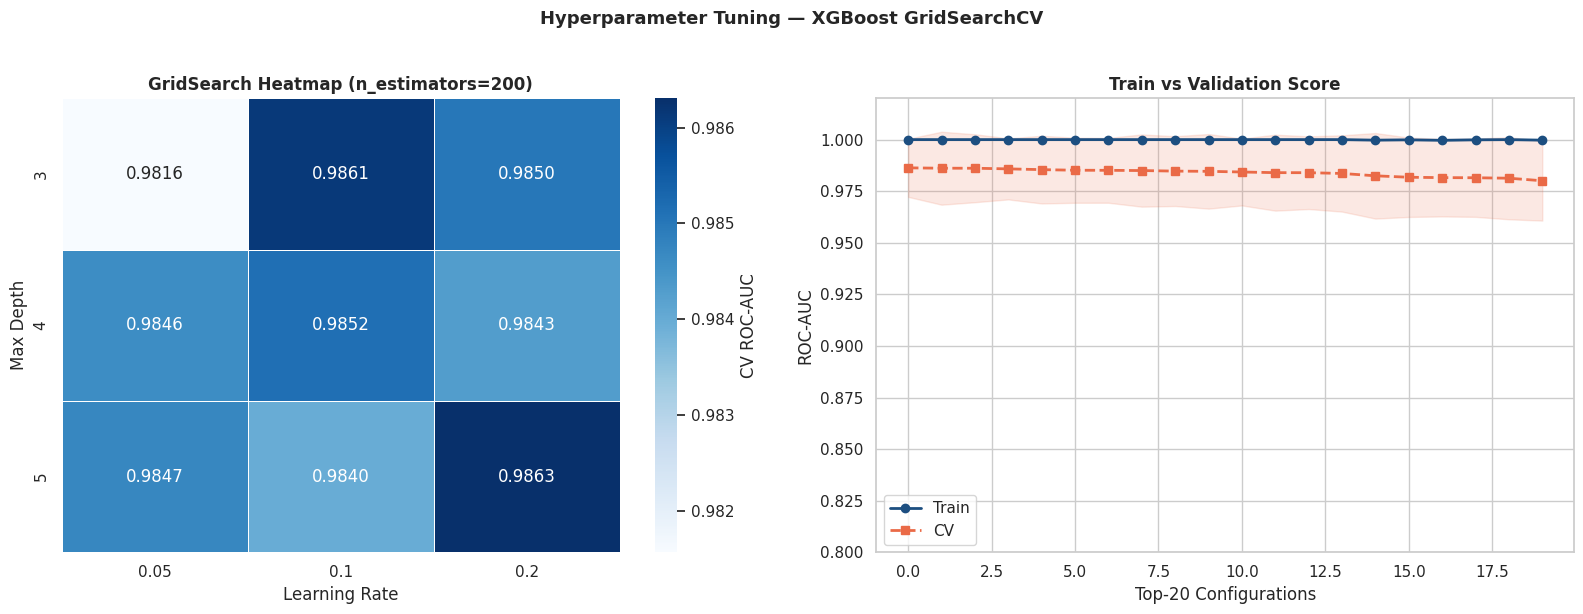

In [13]:
param_grid = {
    'n_estimators'  : [50, 100, 200],
    'max_depth'     : [3, 4, 5],
    'learning_rate' : [0.05, 0.10, 0.20],
}
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_gs = GridSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False,
                  eval_metric='logloss',
                  scale_pos_weight=(yc_tr==0).sum()/(yc_tr==1).sum()),
    param_grid, cv=cv_inner, scoring='roc_auc',
    n_jobs=-1, return_train_score=True, verbose=0
)
print('Tuning XGBoost (27 combos x 5 folds = 135 fits)...')
xgb_gs.fit(X_train, yc_tr)
best_xgb = xgb_gs.best_estimator_

print()
print('=' * 50)
print(' Best XGBoost Configuration')
print('=' * 50)
for k, v in xgb_gs.best_params_.items():
    print(f'  {k:<20} : {v}')
print(f'  Best CV ROC-AUC  : {xgb_gs.best_score_:.4f}')
print(f'  Std Dev (±)      : {xgb_gs.cv_results_["std_test_score"][xgb_gs.best_index_]:.4f}')

res_df   = pd.DataFrame(xgb_gs.cv_results_)
best_n   = xgb_gs.best_params_['n_estimators']
pivot_gs = res_df[res_df['param_n_estimators']==best_n].pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_learning_rate'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(pivot_gs, annot=True, fmt='.4f', cmap='Blues',
            linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'CV ROC-AUC'})
axes[0].set_title(f'GridSearch Heatmap (n_estimators={best_n})',
                  fontweight='bold')
axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('Max Depth')

top20 = res_df.nlargest(20, 'mean_test_score').reset_index(drop=True)
x = range(20)
axes[1].plot(x, top20['mean_train_score'], 'o-',
             color=COLORS['primary'], label='Train', lw=2)
axes[1].plot(x, top20['mean_test_score'], 's--',
             color=COLORS['accent'], label='CV', lw=2)
axes[1].fill_between(x,
    top20['mean_test_score'] - top20['std_test_score'],
    top20['mean_test_score'] + top20['std_test_score'],
    alpha=0.15, color=COLORS['accent'])
axes[1].set_title('Train vs Validation Score', fontweight='bold')
axes[1].set_xlabel('Top-20 Configurations')
axes[1].set_ylabel('ROC-AUC')
axes[1].legend()
axes[1].set_ylim(0.80, 1.02)

plt.suptitle('Hyperparameter Tuning — XGBoost GridSearchCV',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('p3_viz2_tuning.png', bbox_inches='tight')
plt.show()


## Step 14: Train All 4 Models & Comparison Table

In [14]:
models = {
    'Logistic Regression': {
        'model' : LogisticRegression(max_iter=1000, random_state=42,
                                      class_weight='balanced', C=1.0),
        'scaled': True, 'color': COLORS['green'],
    },
    'Random Forest': {
        'model' : RandomForestClassifier(n_estimators=100, random_state=42,
                                          class_weight='balanced', max_depth=8),
        'scaled': False, 'color': COLORS['secondary'],
    },
    'Gradient Boosting': {
        'model' : GradientBoostingClassifier(
                      n_estimators=xgb_gs.best_params_['n_estimators'],
                      max_depth=xgb_gs.best_params_['max_depth'],
                      learning_rate=xgb_gs.best_params_['learning_rate'],
                      random_state=42),
        'scaled': False, 'color': COLORS['primary'],
    },
    'XGBoost (Tuned)': {
        'model': best_xgb, 'scaled': False, 'color': COLORS['accent'],
    },
}

print('Training all 4 models...')
for name, info in models.items():
    Xt = Xs_tr if info['scaled'] else X_train
    info['model'].fit(Xt, yc_tr)
    Xe = Xs_te if info['scaled'] else X_test
    info['prob'] = info['model'].predict_proba(Xe)[:, 1]
    info['pred'] = info['model'].predict(Xe)
    info['auc']  = roc_auc_score(yc_te, info['prob'])
    info['pr']   = average_precision_score(yc_te, info['prob'])
    print(f'  {name:<25} ROC-AUC = {info["auc"]:.4f}')

rows = []
for name, info in models.items():
    rows.append({
        'Model'    : name,
        'Precision': round(precision_score(yc_te, info['pred'], zero_division=0), 4),
        'Recall'   : round(recall_score(yc_te, info['pred']), 4),
        'F1'       : round(f1_score(yc_te, info['pred']), 4),
        'ROC-AUC'  : round(info['auc'], 4),
        'PR-AUC'   : round(info['pr'], 4),
    })

summary = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print()
print('=' * 70)
print(f' 4-MODEL COMPARISON — {SELECTED_PRODUCT}')
print('=' * 70)
display(summary)
print(f'Best model: {summary.iloc[0]["Model"]}')


Training all 4 models...
  Logistic Regression       ROC-AUC = 0.5423
  Random Forest             ROC-AUC = 0.7231
  Gradient Boosting         ROC-AUC = 0.9718
  XGBoost (Tuned)           ROC-AUC = 0.9711

 4-MODEL COMPARISON — ContactMatcher


,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Gradient Boosting,0.9697,0.9143,0.9412,0.9718,0.9694
1,XGBoost (Tuned),0.8684,0.9429,0.9041,0.9711,0.9331
2,Random Forest,0.5789,0.3143,0.4074,0.7231,0.3958
3,Logistic Regression,0.1839,0.4571,0.2623,0.5423,0.2043


Best model: Gradient Boosting


## Step 15: Cross Validation + Confusion Matrices

5-Fold CV Results:
  Logistic Regression       0.5528 ± 0.0559
  Random Forest             0.7479 ± 0.0526
  Gradient Boosting         0.9855 ± 0.0103
  XGBoost (Tuned)           0.9844 ± 0.0076


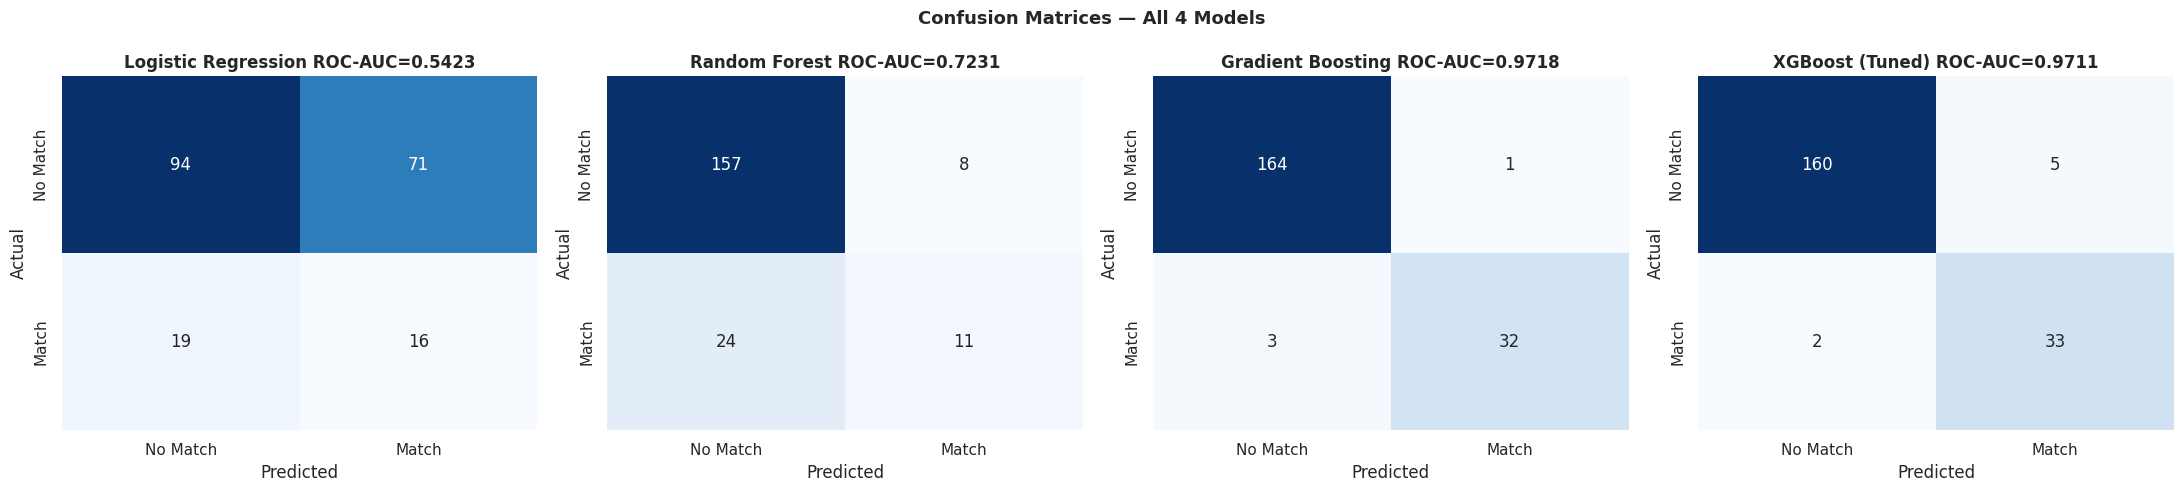

In [15]:
cv_outer  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('5-Fold CV Results:')
for name, info in models.items():
    from sklearn.pipeline import Pipeline
    if info['scaled']:
        m = Pipeline([('s', StandardScaler()), ('m', info['model'])])
    else:
        m = info['model']
    scores = cross_val_score(m, X, y_cls, cv=cv_outer,
                              scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'  {name:<25} {scores.mean():.4f} ± {scores.std():.4f}')

# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (name, info) in zip(axes, models.items()):
    cm = confusion_matrix(yc_te, info['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=ax, cbar=False,
                xticklabels=['No Match','Match'],
                yticklabels=['No Match','Match'])
    ax.set_title(f'{name} ROC-AUC={info["auc"]:.4f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All 4 Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('p3_viz3_confusion.png', bbox_inches='tight')
plt.show()


## Step 16: ROC & Precision-Recall Curves

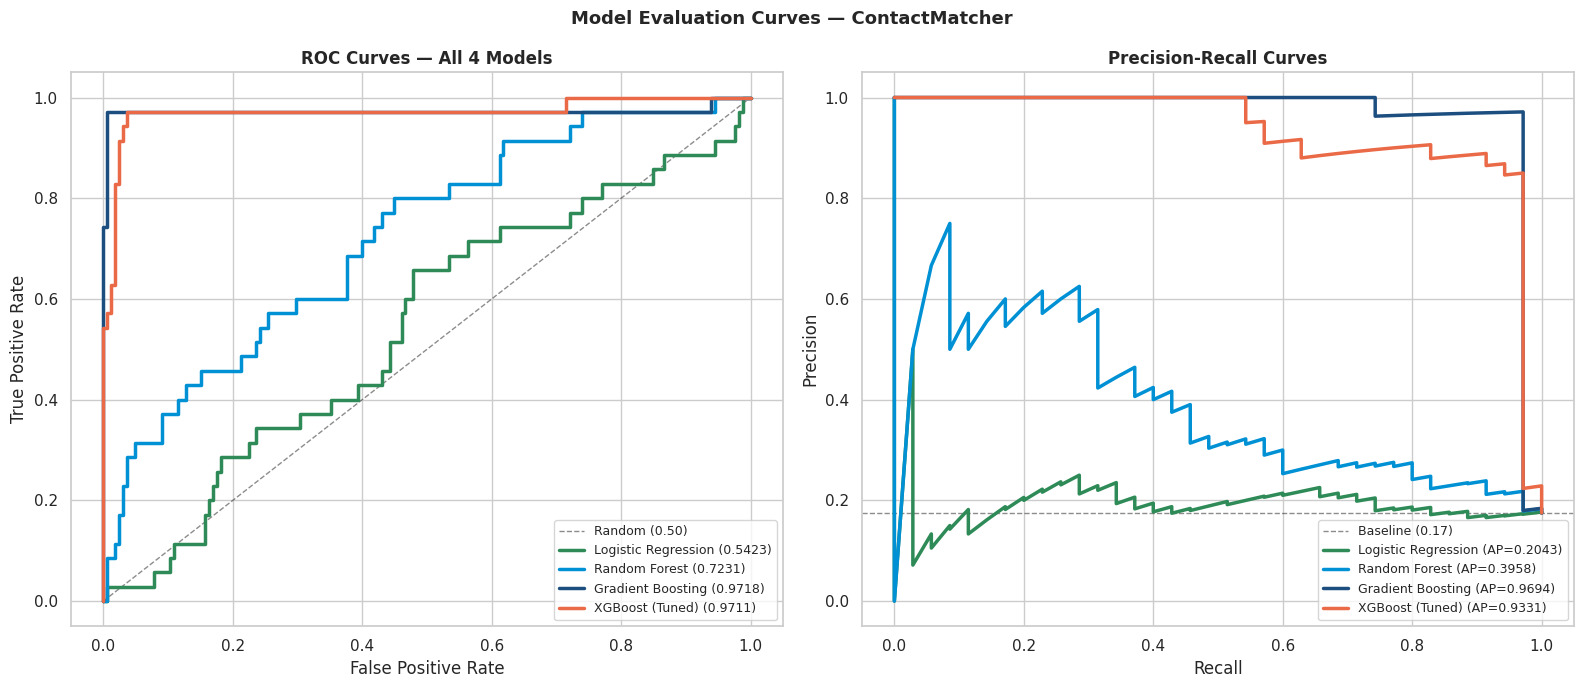

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Random (0.50)')
for name, info in models.items():
    fpr, tpr, _ = roc_curve(yc_te, info['prob'])
    axes[0].plot(fpr, tpr, lw=2.5, color=info['color'],
                 label=f'{name} ({info["auc"]:.4f})')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All 4 Models', fontweight='bold')
axes[0].legend(fontsize=9, loc='lower right')

axes[1].axhline(yc_te.mean(), color='k', linestyle='--', lw=1, alpha=0.5,
                label=f'Baseline ({yc_te.mean():.2f})')
for name, info in models.items():
    p, r, _ = precision_recall_curve(yc_te, info['prob'])
    ap = average_precision_score(yc_te, info['prob'])
    axes[1].plot(r, p, lw=2.5, color=info['color'],
                 label=f'{name} (AP={ap:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle(f'Model Evaluation Curves — {SELECTED_PRODUCT}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('p3_viz4_roc_pr.png', bbox_inches='tight')
plt.show()


## Step 17: Per-Product Models — All 14 Products

In [17]:
per_product_results = {}
per_product_top5    = {}

print('=' * 75)
print(' PER-PRODUCT XGBoost RESULTS')
print('=' * 75)
print(f'{"Product":<30} {"Pos%":>6} {"ROC-AUC":>10}   {"Top Company"}')
print('-' * 75)

for prod in sorted(saas['Product'].unique()):
    y_prod = product_labels[prod].copy()
    if y_prod.sum() < 10:
        continue
    Xt, Xe, yt, ye = train_test_split(
        X, y_prod, test_size=0.20, random_state=42, stratify=y_prod
    )
    m = XGBClassifier(
        n_estimators=xgb_gs.best_params_['n_estimators'],
        max_depth=xgb_gs.best_params_['max_depth'],
        learning_rate=xgb_gs.best_params_['learning_rate'],
        random_state=42, use_label_encoder=False, eval_metric='logloss',
        scale_pos_weight=(yt==0).sum()/(yt==1).sum() if yt.sum()>0 else 1
    )
    m.fit(Xt, yt)
    probs = m.predict_proba(X)[:, 1]
    try:
        auc = roc_auc_score(ye, m.predict_proba(Xe)[:, 1])
    except:
        auc = 0.0

    df_temp = df.copy()
    df_temp['score'] = probs
    df_temp['label'] = y_prod.values
    top5 = df_temp.nlargest(5, 'score')[['name','industry','score','label']]

    per_product_results[prod] = {'auc': auc, 'probs': probs, 'model': m}
    per_product_top5[prod]    = top5
    print(f'{prod:<30} {y_prod.mean()*100:>5.1f}% {auc:>10.4f}   {top5.iloc[0]["name"]}')


 PER-PRODUCT XGBoost RESULTS
Product                          Pos%    ROC-AUC   Top Company
---------------------------------------------------------------------------
Alchemy                         18.6%     0.9831   Alexander Investment Services
Big Ol Database                 14.5%     0.9915   Fram Insurance Brokers
ChatBot Plugin                  16.5%     0.9947   ShopTheRate
ContactMatcher                  17.4%     0.9711   360 ONE Wealth
Data Smasher                    22.6%     0.9791   360 ONE Wealth
FinanceHub                      24.5%     0.9930   Qianhai First Investment
Marketing Suite                 16.5%     0.9947   ShopTheRate
Marketing Suite - Gold          17.4%     0.9711   360 ONE Wealth
OneView                         22.1%     0.9977   SEMA
SaaS Connector Pack             18.5%     0.9993   Building Blocks Financial Planning
SaaS Connector Pack - Gold      18.6%     0.9831   Alexander Investment Services
Site Analytics                  16.5%     0.9947   Sho

## Step 18: SHAP — Global & Local Explanations

 GLOBAL SHAP — ContactMatcher
  1   industry_enc                   4.7339
  2   reply_rate_pct                 0.3920
  3   employee_range_enc             0.2456
  4   employee_count_est             0.2108
  5   deal_potential_usd             0.2025
  6   active_tech_count              0.1949
  7   crm_completeness_pct           0.1942
  8   email_engagement_score         0.1867
  9   log_web_visits_30d             0.1758
  10  days_since_last_contact        0.1669


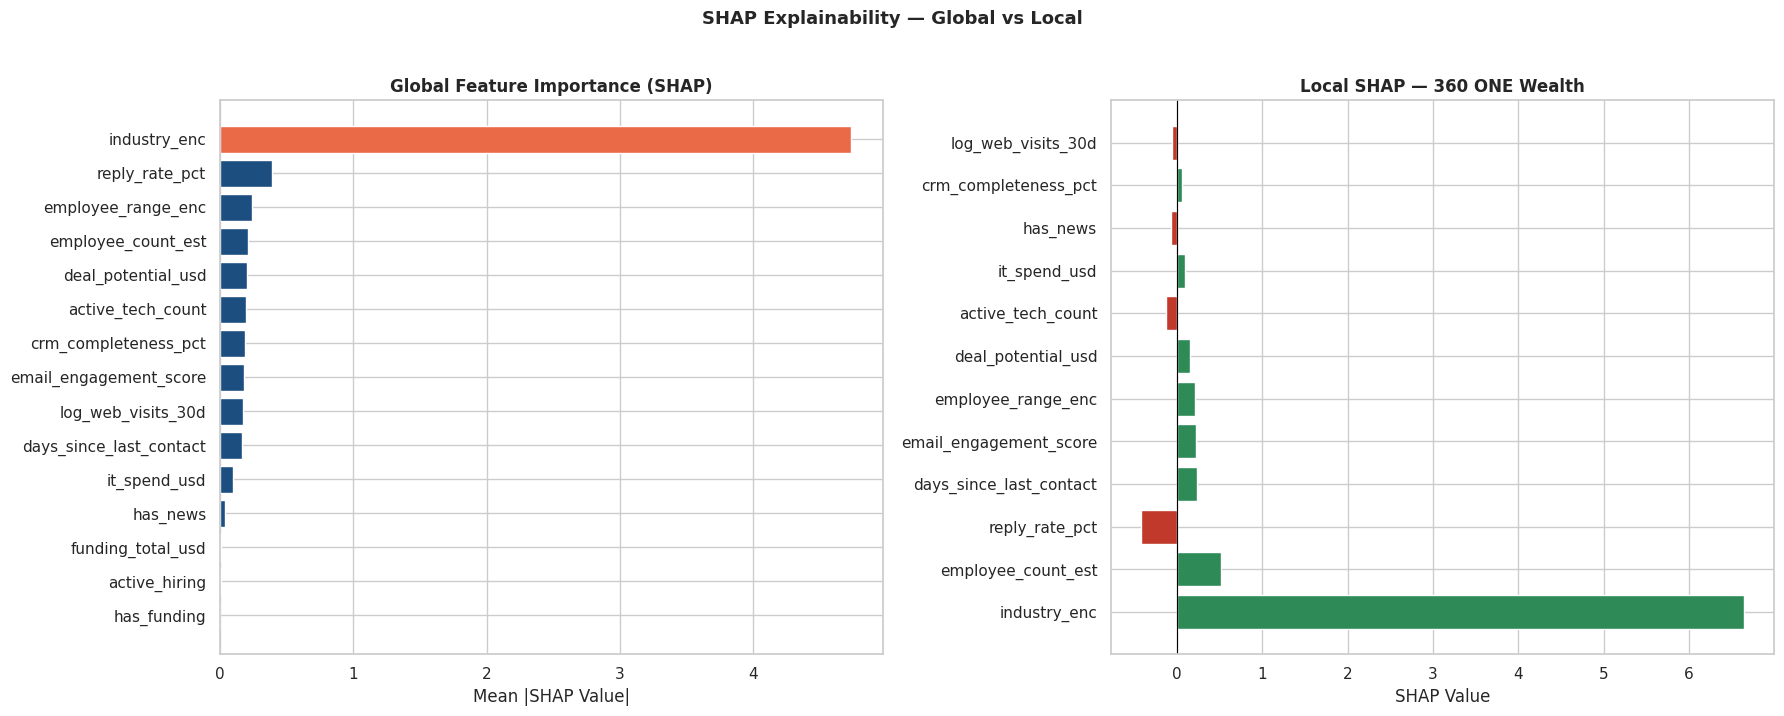

Top company: 360 ONE Wealth
Industry: Financial Services
Conversion probability: 99.9%


In [18]:
explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X)

mean_shap = np.abs(shap_values).mean(axis=0)
fi_df = pd.DataFrame({
    'Feature': FEATURE_COLS, 'SHAP_Mean': mean_shap
}).sort_values('SHAP_Mean', ascending=False)

print('=' * 55)
print(f' GLOBAL SHAP — {SELECTED_PRODUCT}')
print('=' * 55)
for i, (_, row) in enumerate(fi_df.head(10).iterrows(), 1):
    print(f'  {i:<3} {row["Feature"]:<30} {row["SHAP_Mean"]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Global bar
top15 = fi_df.head(15).sort_values('SHAP_Mean', ascending=True)
bar_colors = [COLORS['accent'] if v == top15['SHAP_Mean'].max()
              else COLORS['primary'] for v in top15['SHAP_Mean']]
axes[0].barh(top15['Feature'], top15['SHAP_Mean'],
             color=bar_colors, edgecolor='white')
axes[0].set_xlabel('Mean |SHAP Value|')
axes[0].set_title(f'Global Feature Importance (SHAP)', fontweight='bold')

# Local SHAP
probs_all = best_xgb.predict_proba(X)[:, 1]
top_idx   = probs_all.argmax()
top_name  = df.iloc[top_idx]['name']
sv_local  = shap_values[top_idx]

local_df = pd.DataFrame({
    'Feature': FEATURE_COLS, 'SHAP': sv_local
}).sort_values('SHAP', key=abs, ascending=False).head(12)

local_colors = ['#2E8B57' if v > 0 else '#C0392B' for v in local_df['SHAP']]
axes[1].barh(local_df['Feature'], local_df['SHAP'],
             color=local_colors, edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('SHAP Value')
axes[1].set_title(f'Local SHAP — {top_name}', fontweight='bold')

plt.suptitle('SHAP Explainability — Global vs Local',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('p3_viz5_shap.png', bbox_inches='tight')
plt.show()

print(f'Top company: {top_name}')
print(f'Industry: {df.iloc[top_idx]["industry"]}')
print(f'Conversion probability: {probs_all[top_idx]:.1%}')


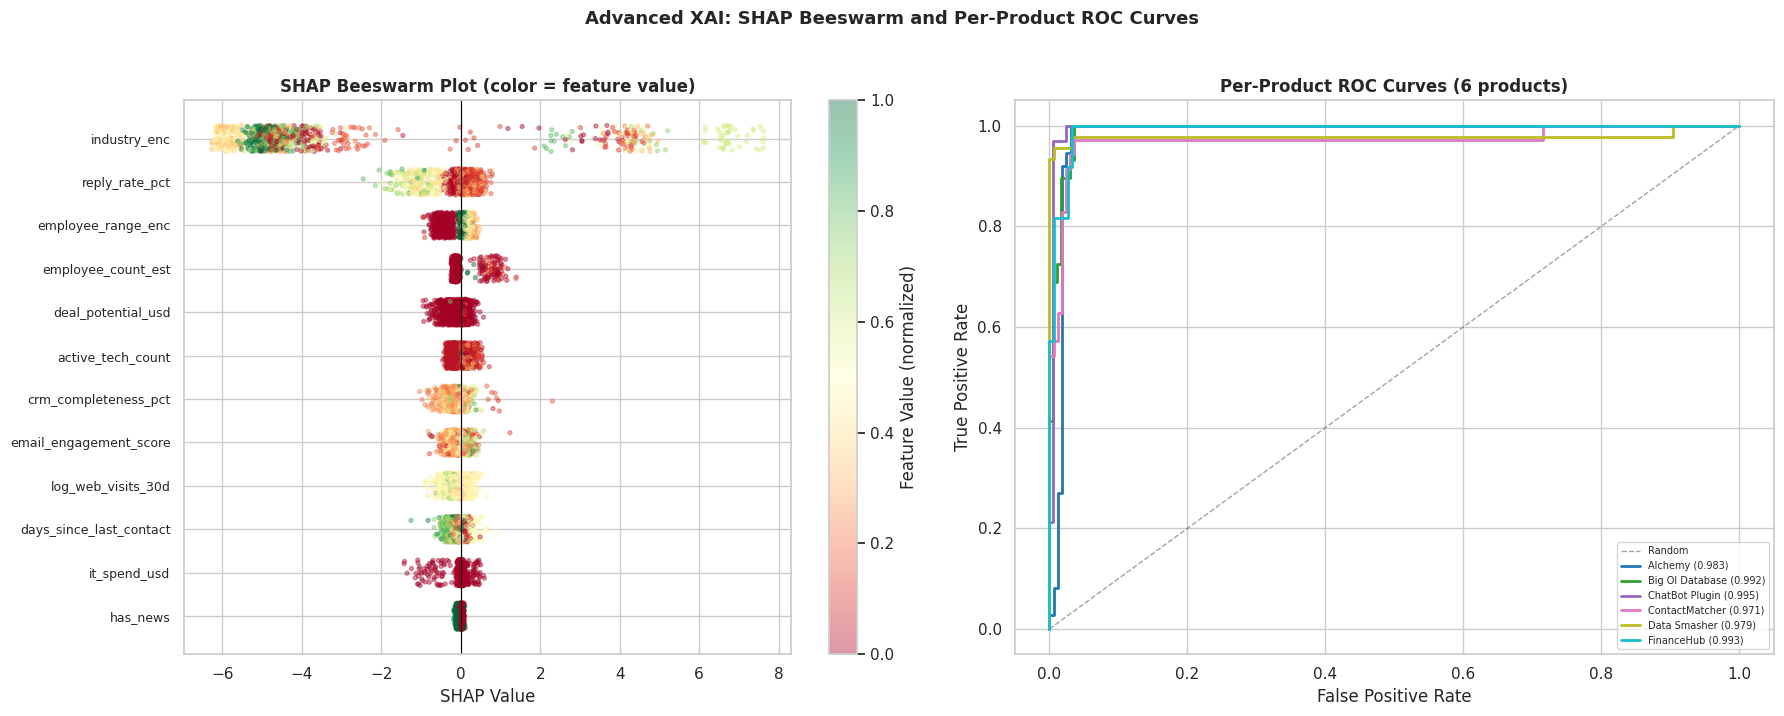

In [32]:
# SHAP Beeswarm + Per-Product ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Beeswarm
mean_shap_vals = np.abs(shap_values).mean(axis=0)
fi_order = np.argsort(mean_shap_vals)[-12:]
feat_names = [FEATURE_COLS[i] for i in fi_order]

for j, idx in enumerate(fi_order):
    vals    = shap_values[:, idx]
    feat_vs = X.iloc[:, idx].values
    norm_fv = (feat_vs - feat_vs.min()) / (feat_vs.max() - feat_vs.min() + 1e-9)
    scatter = axes[0].scatter(
        vals,
        np.full_like(vals, j) + np.random.uniform(-0.3, 0.3, len(vals)),
        c=norm_fv, cmap='RdYlGn', alpha=0.4, s=8
    )

axes[0].set_yticks(range(len(feat_names)))
axes[0].set_yticklabels(feat_names, fontsize=9)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_xlabel('SHAP Value')
axes[0].set_title('SHAP Beeswarm Plot (color = feature value)', fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Feature Value (normalized)')

# Per-product ROC
products_sample = list(per_product_results.keys())[:6]
axes[1].plot([0,1],[0,1],'k--',lw=1,alpha=0.4,label='Random')
colors_roc = plt.cm.tab10(np.linspace(0, 1, len(products_sample)))
for prod, color in zip(products_sample, colors_roc):
    m    = per_product_results[prod]['model']
    y_p  = product_labels[prod].copy()
    _, Xe, _, ye = train_test_split(X, y_p, test_size=0.20, random_state=42, stratify=y_p)
    probs_roc = m.predict_proba(Xe)[:, 1]
    try:
        fpr, tpr, _ = roc_curve(ye, probs_roc)
        auc_val     = roc_auc_score(ye, probs_roc)
        axes[1].plot(fpr, tpr, lw=2, color=color,
                     label=f'{prod[:15]} ({auc_val:.3f})')
    except:
        pass

axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Per-Product ROC Curves (6 products)', fontweight='bold')
axes[1].legend(fontsize=7, loc='lower right')

plt.suptitle('Advanced XAI: SHAP Beeswarm and Per-Product ROC Curves',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_beeswarm_roc.png', bbox_inches='tight')
plt.show()

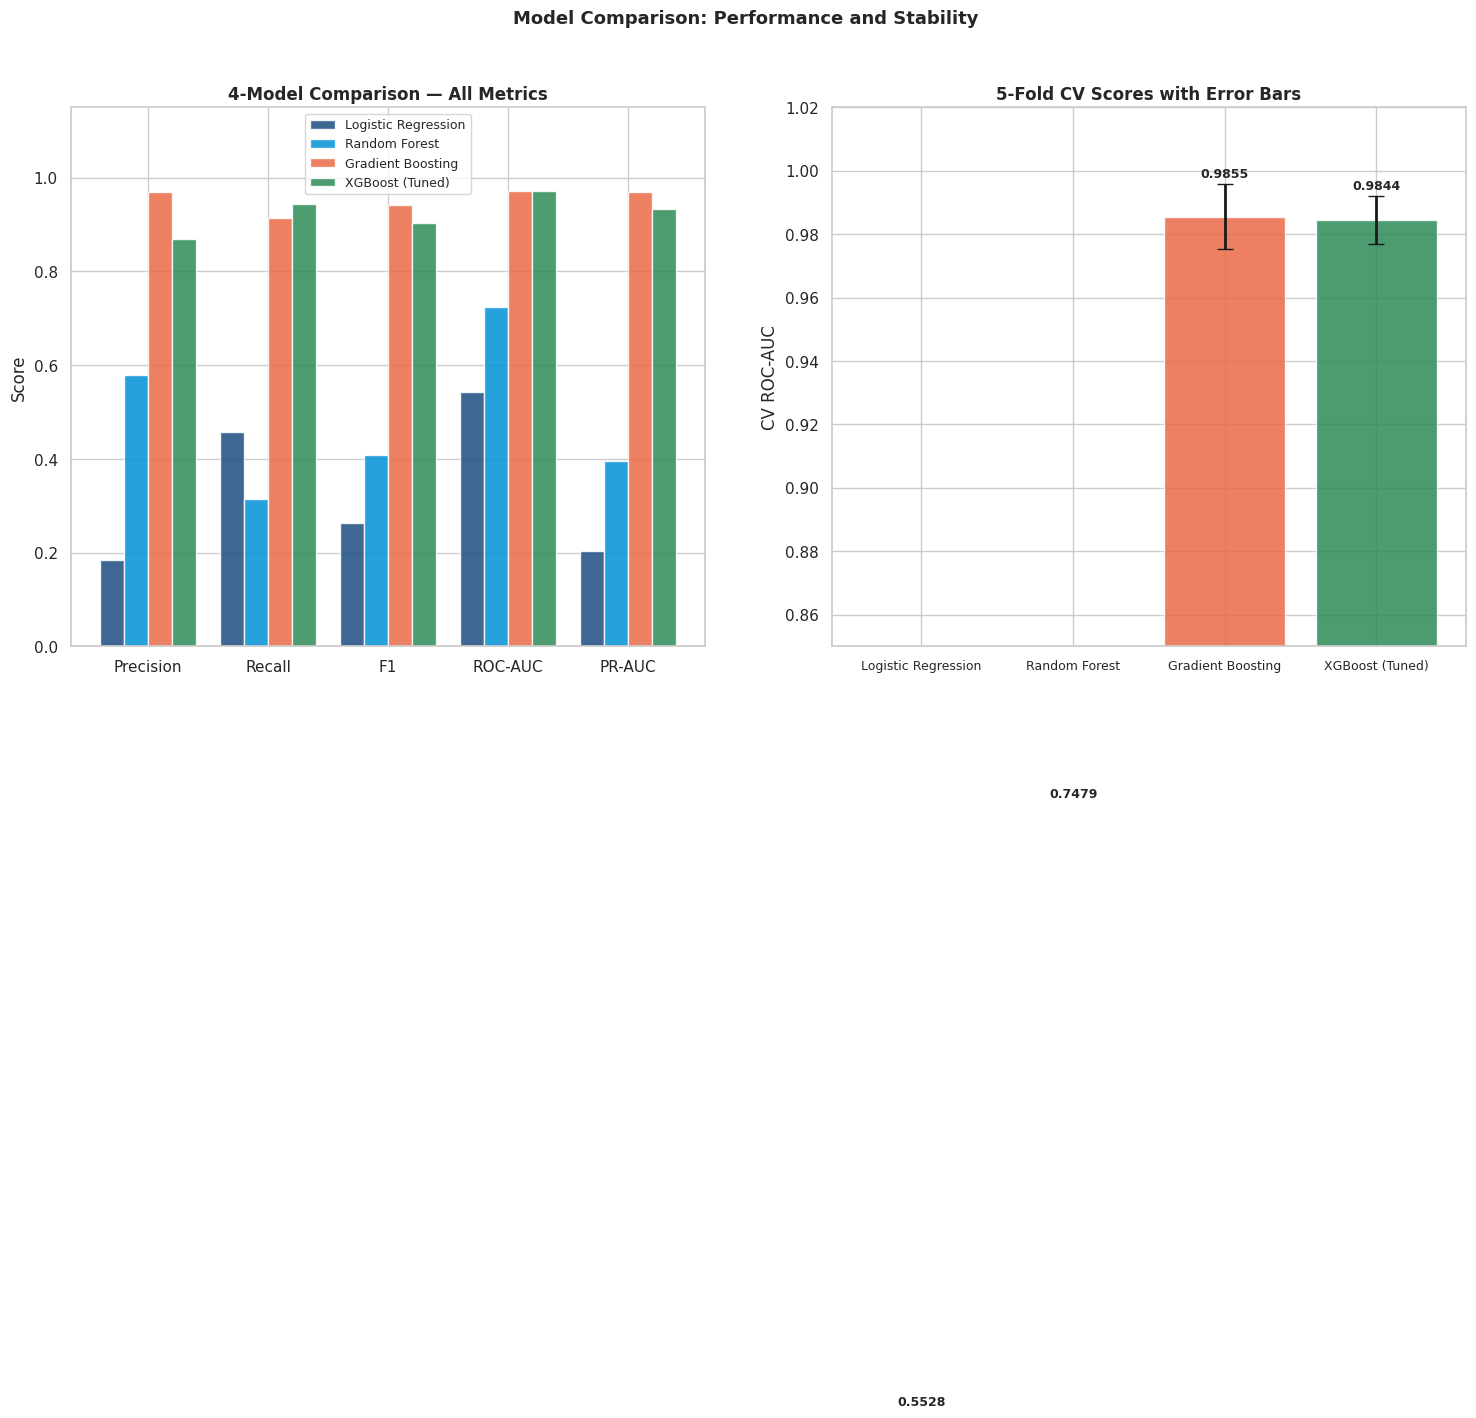

In [33]:
# Model Comparison Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

metrics_list = ['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
x = np.arange(len(metrics_list))
width = 0.2

for i, (name, info) in enumerate(models.items()):
    vals = [
        round(precision_score(yc_te, info['pred'], zero_division=0), 4),
        round(recall_score(yc_te, info['pred']), 4),
        round(f1_score(yc_te, info['pred']), 4),
        round(info['auc'], 4),
        round(info['pr'], 4),
    ]
    axes[0].bar(x + i*width, vals, width, label=name,
                color=list(COLORS.values())[i], alpha=0.85, edgecolor='white')

axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(metrics_list)
axes[0].set_ylabel('Score')
axes[0].set_title('4-Model Comparison — All Metrics', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.15)

# CV with error bars
cv_means = [cv_results[name].mean() for name in models.keys()]
cv_stds  = [cv_results[name].std()  for name in models.keys()]
bar_colors = [list(COLORS.values())[i] for i in range(len(models))]

axes[1].bar(range(len(models)), cv_means, yerr=cv_stds,
             color=bar_colors, alpha=0.85, edgecolor='white',
             capsize=6, error_kw={'linewidth':2})
axes[1].set_xticks(range(len(models)))
axes[1].set_xticklabels([n.replace(' ', ' ') for n in models.keys()], fontsize=9)
axes[1].set_ylabel('CV ROC-AUC')
axes[1].set_title('5-Fold CV Scores with Error Bars', fontweight='bold')
axes[1].set_ylim(0.85, 1.02)

for i, (m, s) in enumerate(zip(cv_means, cv_stds)):
    axes[1].text(i, m + s + 0.002, f'{m:.4f}',
                 ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison: Performance and Stability',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_model_comparison_bar.png', bbox_inches='tight')
plt.show()

## Step 19: LIME — Local Interpretable Explanations

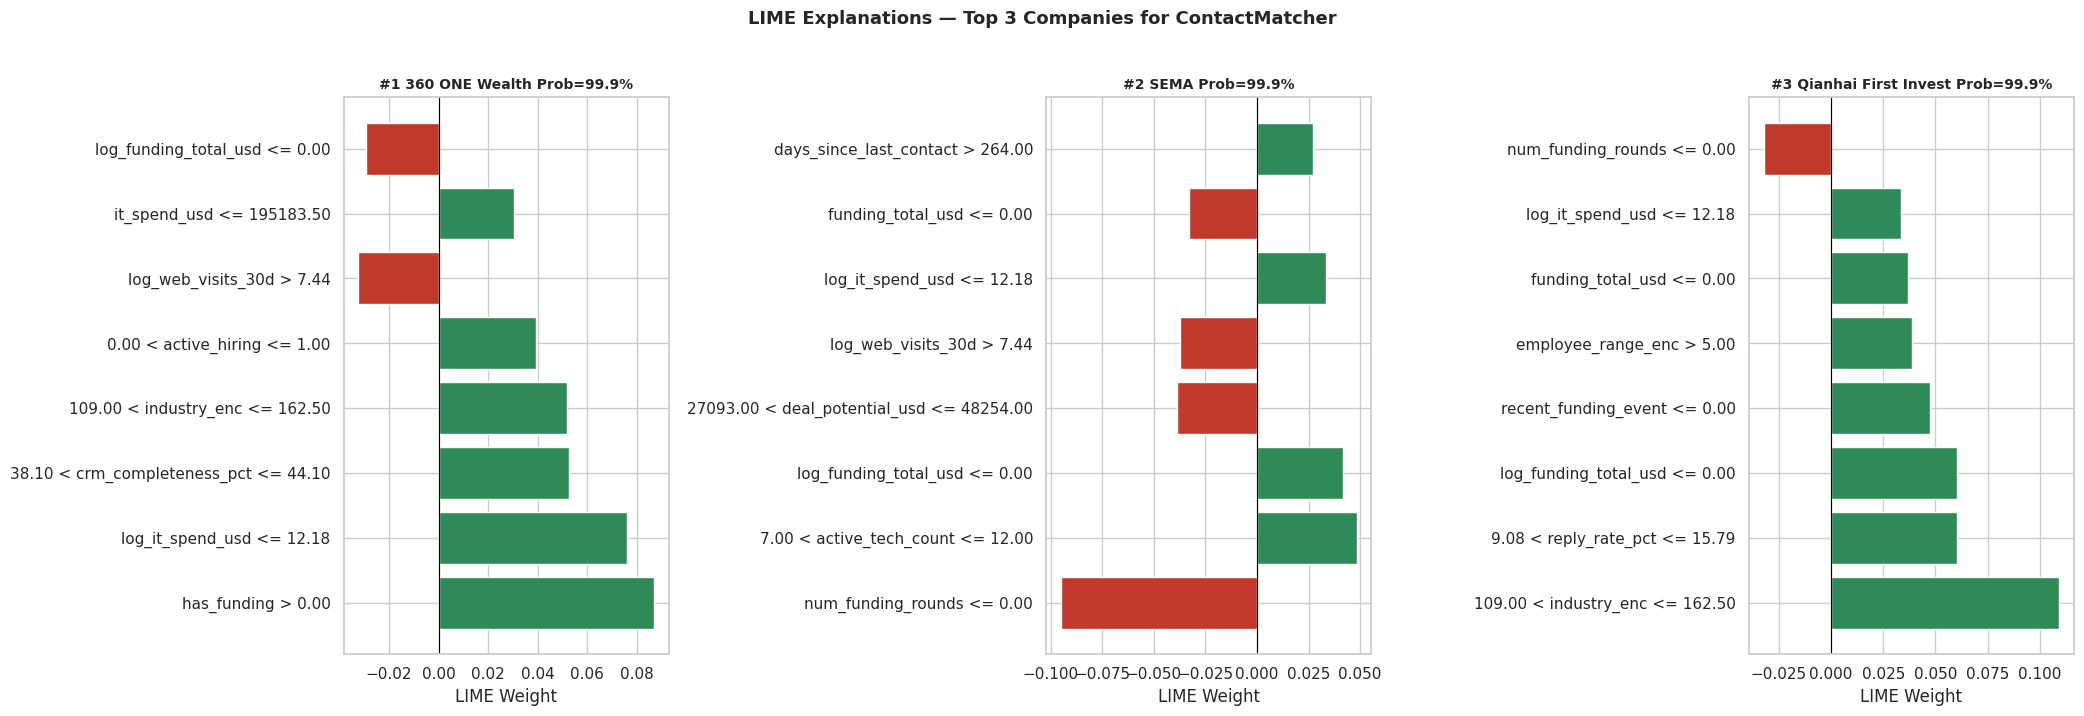

In [19]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data        = X_train.values,
    feature_names        = FEATURE_COLS,
    class_names          = ['No Match', 'Product Match'],
    mode                 = 'classification',
    random_state         = 42,
    discretize_continuous= True,
)

top3_idx = np.argsort(probs_all)[::-1][:3]
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for plot_i, idx in enumerate(top3_idx):
    exp = lime_explainer.explain_instance(
        X.iloc[idx].values, best_xgb.predict_proba,
        num_features=8, num_samples=500,
    )
    lime_feats = exp.as_list()
    feats  = [f[0] for f in lime_feats]
    vals   = [f[1] for f in lime_feats]
    lcolors = ['#2E8B57' if v > 0 else '#C0392B' for v in vals]

    axes[plot_i].barh(feats, vals, color=lcolors, edgecolor='white')
    axes[plot_i].axvline(0, color='black', lw=0.8)
    axes[plot_i].set_title(f'#{plot_i+1} {df.iloc[idx]["name"][:20]} Prob={probs_all[idx]:.1%}', fontweight='bold', fontsize=10)
    axes[plot_i].set_xlabel('LIME Weight')

plt.suptitle(f'LIME Explanations — Top 3 Companies for {SELECTED_PRODUCT}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('p3_viz6_lime.png', bbox_inches='tight')
plt.show()


## Step 20: Ranking Metrics — P@K, NDCG@K, MAP@K

In [20]:
def precision_at_k(y_true, scores, k):
    idx = np.argsort(scores)[::-1][:k]
    y   = y_true.iloc[idx] if hasattr(y_true, 'iloc') else y_true[idx]
    return y.mean()

def ndcg_at_k(y_true, scores, k):
    idx   = np.argsort(scores)[::-1][:k]
    gains = (y_true.iloc[idx].values if hasattr(y_true,'iloc') else y_true[idx]).astype(float)
    disc  = np.log2(np.arange(2, k+2))
    dcg   = (gains / disc).sum()
    ideal = np.sort(y_true.values if hasattr(y_true,'values') else y_true)[::-1][:k].astype(float)
    idcg  = (ideal / disc[:len(ideal)]).sum()
    return dcg / idcg if idcg > 0 else 0.0

def map_at_k(y_true, scores, k):
    idx = np.argsort(scores)[::-1][:k]
    y_s = y_true.iloc[idx].values if hasattr(y_true,'iloc') else y_true[idx]
    if y_s.sum() == 0: return 0.0
    hits, ps = 0, 0.0
    for i, v in enumerate(y_s, 1):
        if v: hits += 1; ps += hits/i
    return ps / y_s.sum()

y_test_r = yc_te.reset_index(drop=True)
k_vals   = [5, 10, 20, 50]
rows     = []

for name, info in models.items():
    Xe = Xs_te if info['scaled'] else X_test
    pt = info['model'].predict_proba(Xe)[:, 1]
    for k in k_vals:
        rows.append({
            'Model' : name, 'K': k,
            'P@K'   : round(precision_at_k(y_test_r, pt, k), 4),
            'NDCG@K': round(ndcg_at_k(y_test_r, pt, k), 4),
            'MAP@K' : round(map_at_k(y_test_r, pt, k), 4),
        })

rank_df = pd.DataFrame(rows)
print('=' * 75)
print(f' RANKING METRICS — {SELECTED_PRODUCT}')
print('=' * 75)
display(rank_df.pivot_table(
    values=['P@K','NDCG@K','MAP@K'],
    index='K', columns='Model'
).round(4))


 RANKING METRICS — ContactMatcher


MAP@K                                                    \
Model Gradient Boosting Logistic Regression Random Forest XGBoost (Tuned)   
K                                                                           
5                1.0000              0.5000        0.6389          1.0000   
10               1.0000              0.5000        0.6073          1.0000   
20               1.0000              0.2611        0.6042          1.0000   
50               0.9925              0.2235        0.5491          0.9538   

                 NDCG@K                                                    \
Model Gradient Boosting Logistic Regression Random Forest XGBoost (Tuned)   
K                                                                           
5                1.0000              0.2140        0.5296          1.0000   
10               1.0000              0.1389        0.5469          1.0000   
20               1.0000              0.1575        0.5318          0.9677   
50               0.9795              0.2631        0.4664          0.9714   

                    P@K                                                    
Model Gradient Boosting Logistic Regression Random Forest XGBoost (Tuned)  
K                                                                          
5                  1.00                0.20          0.60            1.00  
10                 1.00                0.10          0.60            1.00  
20                 1.00                0.15          0.55            0.95  
50                 0.68                0.22          0.32            0.68

## Step 21: Top 10 Company Ranking — Final Demo

 TOP 10 COMPANIES TO SELL: "ContactMatcher"


,name,industry,country_code,employee_range,conversion_prob,active_hiring,recent_funding_event,reply_rate_pct,deal_potential_usd
1,360 ONE Wealth,Financial Services,IN,501-1000,99.9%,1,0,18.00,386336
2,SEMA,Financial Services,KR,Unknown,99.9%,1,0,15.99,40500
3,Qianhai First Investment,Finance,Unknown,Unknown,99.9%,1,0,9.61,32597
4,Sigma Capital Group,Finance,GB,501-1000,99.9%,0,1,11.46,443638
5,XCHANGER.IO,Finance,GB,1-10,99.9%,1,0,26.40,12486
6,Alexander Investment Services,Financial Services,US,11-50,99.9%,0,0,5.87,25906
7,Cash For My Miles,Financial Services,US,11-50,99.9%,1,0,22.85,26809
8,Alliance Financial Services,Financial Services,JM,51-100,99.9%,1,0,8.71,56027
9,"Span Construction and Engineering, Inc.",Building Material,US,101-250,99.9%,0,0,5.15,273390
10,ConnexMarkets,Financial Services,US,1-10,99.9%,1,0,9.88,27859


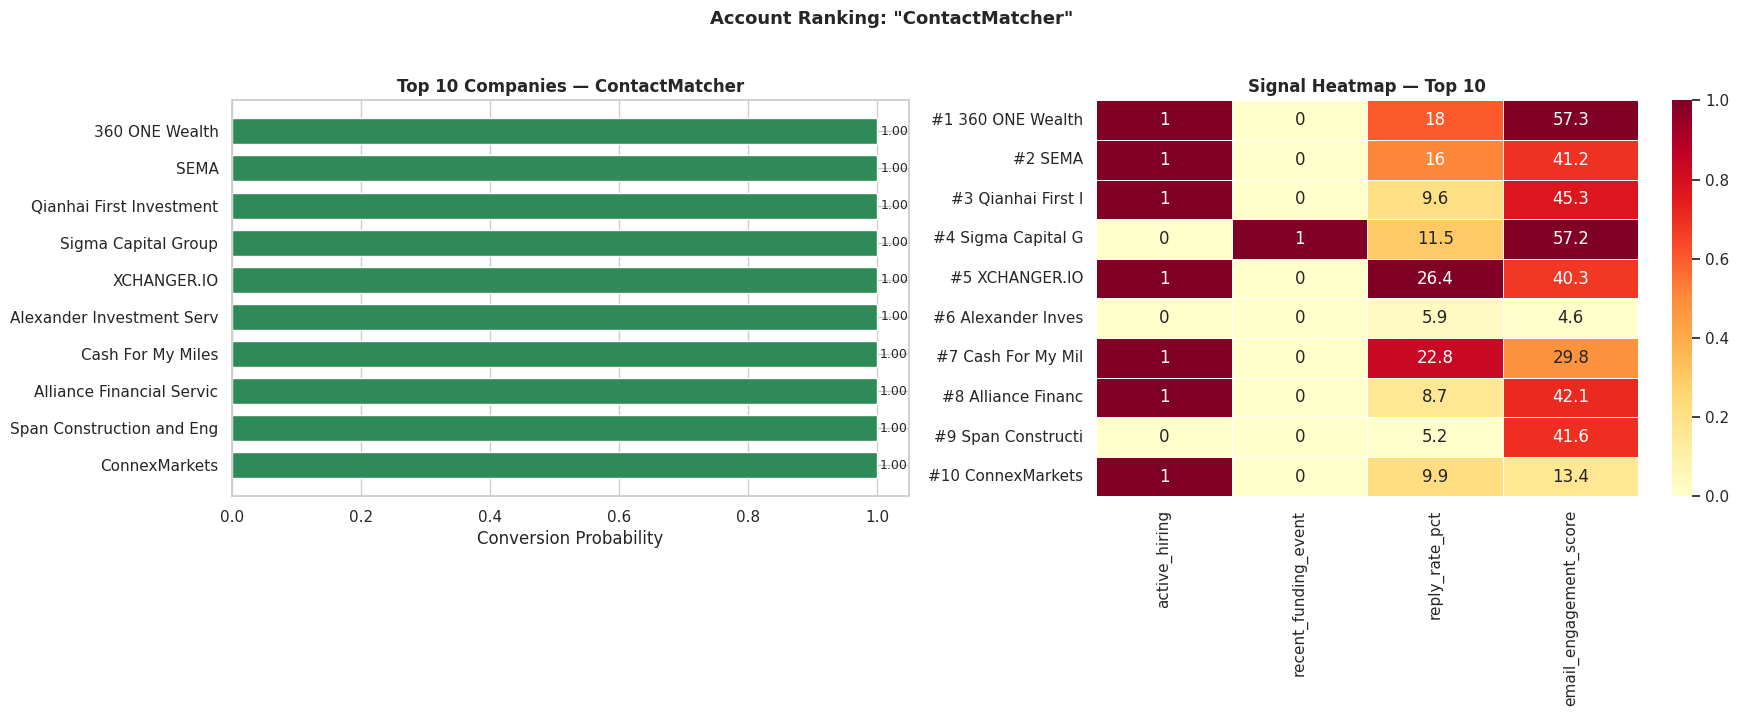

In [21]:
df_ranked = df.copy()
df_ranked['conversion_prob'] = best_xgb.predict_proba(X)[:, 1]
df_ranked['product_label']   = product_labels[SELECTED_PRODUCT].values
df_ranked = df_ranked.sort_values('conversion_prob', ascending=False).reset_index(drop=True)

disp_cols = ['name','industry','country_code','employee_range',
             'conversion_prob','active_hiring','recent_funding_event',
             'reply_rate_pct','deal_potential_usd']
disp_cols = [c for c in disp_cols if c in df_ranked.columns]

top10 = df_ranked.head(10)[disp_cols].copy()
top10.index = range(1, 11)
top10['conversion_prob'] = top10['conversion_prob'].map('{:.1%}'.format)

print('=' * 90)
print(f' TOP 10 COMPANIES TO SELL: "{SELECTED_PRODUCT}"')
print('=' * 90)
display(top10)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

scores = df_ranked.head(10)['conversion_prob'] if df_ranked['conversion_prob'].dtype == float else          df_ranked.head(10)['conversion_prob']
# Re-get numeric scores
scores_num = best_xgb.predict_proba(X)[:, 1]
top10_scores = pd.Series(scores_num).nlargest(10).values

bar_colors = ['#2E8B57' if v > 0.7 else COLORS['primary']
              if v > 0.5 else '#AAAAAA' for v in top10_scores]
axes[0].barh(
    df_ranked.head(10)['name'].str[:25][::-1],
    top10_scores[::-1],
    color=bar_colors[::-1], edgecolor='white', height=0.7
)
for bar, val in zip(axes[0].patches, top10_scores[::-1]):
    axes[0].text(val+0.005, bar.get_y()+bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9)
axes[0].set_xlabel('Conversion Probability')
axes[0].set_title(f'Top 10 Companies — {SELECTED_PRODUCT}', fontweight='bold')

# Signal heatmap
hm_cols = [c for c in ['active_hiring','recent_funding_event',
                         'reply_rate_pct','email_engagement_score']
           if c in df_ranked.columns]
hm_data = df_ranked.head(10)[hm_cols].copy()
hm_data.index = [f'#{i+1} {n[:15]}' for i,n in
                  enumerate(df_ranked.head(10)['name'])]
hm_norm = (hm_data - hm_data.min()) / (hm_data.max() - hm_data.min() + 1e-9)
sns.heatmap(hm_norm, annot=hm_data.round(1), fmt='g',
            cmap='YlOrRd', ax=axes[1], linewidths=0.5)
axes[1].set_title('Signal Heatmap — Top 10', fontweight='bold')

plt.suptitle(f'Account Ranking: "{SELECTED_PRODUCT}"',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('p3_viz7_top10.png', bbox_inches='tight')
plt.show()


---
# 💬 Phase 4: RAG Conversational Sales Assistant

## Step 22: Build Knowledge Base

The RAG system indexes all 1,000 company profiles as text documents
using TF-IDF vectorization. Each profile contains all available signals.


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

probs_all = best_xgb.predict_proba(X)[:, 1]

def build_company_profile(row, prob):
    hiring  = 'actively hiring' if row.get('active_hiring', 0) else 'not hiring'
    funded  = 'recently funded' if row.get('recent_funding_event', 0) else 'no recent funding'
    reply   = row.get('reply_rate_pct', 0)
    intent  = row.get('intent_score', 0)
    lead    = row.get('lead_score', 0)
    days    = int(row.get('days_since_last_contact', 999))
    deal    = row.get('deal_potential_usd', 0)
    funding = row.get('funding_total_usd', 0)

    urgency = []
    if row.get('active_hiring', 0):        urgency.append('currently hiring')
    if row.get('recent_funding_event', 0): urgency.append('recently funded')
    if reply > 20:                         urgency.append('high reply rate ' + str(round(reply,1)) + '%')
    if days < 30:                          urgency.append('contacted ' + str(days) + ' days ago')
    if intent > 60:                        urgency.append('high intent ' + str(round(intent,1)))

    urgency_str = ', '.join(urgency) if urgency else 'none'
    parts = [
        'Company: '              + str(row.get('name','Unknown')),
        'Industry: '             + str(row.get('industry','Unknown')),
        'Country: '              + str(row.get('country_code','Unknown')) + ' | Size: ' + str(row.get('employee_range','Unknown')),
        'Funding: $'             + f'{funding:,.0f}' + ' | ' + funded + ' | ' + str(int(row.get('num_funding_rounds',0))) + ' rounds',
        'Hiring: '               + hiring,
        'Reply rate: '           + f'{reply:.1f}%' + ' | Engagement: ' + f'{row.get("email_engagement_score",0):.1f}/100',
        'Days since contact: '   + str(days),
        'Lead score: '           + f'{lead:.1f}/100' + ' | Intent: ' + f'{intent:.1f}/100',
        'Conversion prob: '      + f'{prob:.1%}',
        'Deal potential: $'      + f'{deal:,.0f}',
        'Urgency: '              + urgency_str,
    ]
    return '\n'.join(parts)

docs   = []
metas  = []
for i, (_, row) in enumerate(df.iterrows()):
    if i >= len(probs_all): break
    docs.append(build_company_profile(row, probs_all[i]))
    metas.append({
        'name'          : str(row.get('name','Unknown')),
        'industry'      : str(row.get('industry','Unknown')),
        'conv_prob'     : float(probs_all[i]),
        'active_hiring' : int(row.get('active_hiring', 0)),
        'recent_funding': int(row.get('recent_funding_event', 0)),
        'reply_rate'    : float(row.get('reply_rate_pct', 0)),
        'deal_potential': float(row.get('deal_potential_usd', 0)),
    })

vectorizer   = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(docs)

rag_index = {
    'docs'      : docs,
    'metas'     : metas,
    'vectorizer': vectorizer,
    'matrix'    : tfidf_matrix,
}

print('RAG Knowledge Base Built')
print('  Companies indexed : ' + str(len(docs)))
print('  TF-IDF vocabulary : ' + str(len(vectorizer.vocabulary_)) + ' terms')
print('  Matrix shape      : ' + str(tfidf_matrix.shape))


RAG Knowledge Base Built
  Companies indexed : 1000
  TF-IDF vocabulary : 2645 terms
  Matrix shape      : (1000, 2645)


## Step 23: Retrieval System

In [23]:
def retrieve_companies(query, rag_index, top_k=8):
    """
    Retrieve the most relevant company profiles for a given query
    using TF-IDF cosine similarity.
    """
    q_vec   = rag_index['vectorizer'].transform([query])
    scores  = cosine_similarity(q_vec, rag_index['matrix']).flatten()
    top_idx = np.argsort(scores)[::-1][:top_k]

    results = []
    for idx in top_idx:
        results.append({
            'doc'   : rag_index['docs'][idx],
            'meta'  : rag_index['metas'][idx],
            'score' : float(scores[idx]),
        })
    return results

# Test retrieval
test_queries = [
    'Who should I call today for ContactMatcher?',
    'Which companies are actively hiring in Finance?',
    'Show me recently funded tech companies',
]

for query in test_queries:
    results = retrieve_companies(query, rag_index, top_k=3)
    print(f'Query: {query}')
    print(f'Top 3 retrieved:')
    for i, r in enumerate(results, 1):
        print(f'  #{i} {r["meta"]["name"]:<30} '
              f'prob={r["meta"]["conv_prob"]:.1%} '
              f'sim={r["score"]:.4f}')
    print()


Query: Who should I call today for ContactMatcher?
Top 3 retrieved:
  #1 Catholic Travel Today          prob=0.5% sim=0.3487
  #2 Digital Signage Today          prob=0.1% sim=0.3078
  #3 CSL Executive Fulfillment      prob=0.6% sim=0.0000

Query: Which companies are actively hiring in Finance?
Top 3 retrieved:
  #1 CapStar                        prob=99.8% sim=0.3344
  #2 ShopTheRate                    prob=99.9% sim=0.3219
  #3 Finply                         prob=99.9% sim=0.2956

Query: Show me recently funded tech companies
Top 3 retrieved:
  #1 Shenzhen Wuzhu Tech            prob=95.2% sim=0.4022
  #2 CTJ INFO-TECH                  prob=0.8% sim=0.3509
  #3 Lenzer                         prob=0.1% sim=0.3019



## Step 24: GPT-4o Response Generation

In [29]:
from google.colab import userdata
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY').strip()

def rag_answer(query, rag_index, saas, api_key, top_k=8):
    """
    Full RAG pipeline:
    1. Retrieve relevant company profiles
    2. Build context
    3. Generate grounded response via GPT-4o
    """
    from openai import OpenAI

    # Step 1: Retrieve
    results = retrieve_companies(query, rag_index, top_k=top_k)
    context = '\n\n---\n\n'.join([r['doc'] for r in results])

    # Step 2: Build product stats context
    prod_stats = saas.groupby('Product').agg(
        revenue=('Sales','sum'), transactions=('Sales','count')
    ).sort_values('revenue', ascending=False)
    prod_ctx = '\n'.join([
        '- ' + p + ': $' + f'{r:,.0f}' + ' revenue (' + str(t) + ' deals)'
        for p,(r,t) in prod_stats.iterrows()
    ])

    # Step 3: Generate
    client = OpenAI(api_key=api_key)
    system_prompt = (
        'You are an AI Sales Development Representative assistant.\n'
        'You help SDRs prioritize B2B accounts using data-driven insights.\n\n'
        'PRODUCT CATALOG REVENUE:\n' + prod_ctx + '\n\n'
        'Answer based ONLY on the company profiles provided.\n'
        'Be specific, actionable, and concise.\n'
        'Always mention: company name, industry, conversion probability, and key signals.'
    )

    response = client.chat.completions.create(
        model='gpt-4o',
        messages=[
            {'role': 'system', 'content': system_prompt},
            {'role': 'user',   'content': 'Context:\n' + context + '\n\nQuestion: ' + query}
        ],
        max_tokens=500,
        temperature=0.3,
    )

    answer  = response.choices[0].message.content
    sources = [r['meta']['name'] for r in results[:3]]
    return answer, sources

# Test with multiple queries
queries = [
    'Who should I contact today for ContactMatcher?',
    'Which companies are actively hiring in Finance?',
    'Write me a cold email for the top ranked company',
]

for query in queries:
    print('=' * 60)
    print('Query: ' + query)
    print('=' * 60)
    answer, sources = rag_answer(query, rag_index, saas, OPENAI_API_KEY)
    print(answer)
    print()
    print('Sources: ' + ', '.join(sources))
    print()

Query: Who should I contact today for ContactMatcher?
You should contact **Centricity** in the Advertising industry. Here are the key reasons:

- **Industry Fit**: As an advertising company, Centricity could benefit from ContactMatcher's capabilities in optimizing contact management and enhancing client interactions.
- **Conversion Probability**: Centricity has the highest conversion probability at 1.6% among the listed companies, indicating a better chance of closing a deal.
- **Engagement**: With an engagement score of 25.8/100, Centricity shows relatively higher interest compared to other prospects.
- **Lead Score and Intent**: The lead score of 36.3/100 and intent of 33.4/100 suggest a moderate level of interest and potential readiness to engage.

Given these factors, Centricity presents the most promising opportunity for ContactMatcher today.

Sources: Catholic Travel Today, Digital Signage Today, Angel Business

Query: Which companies are actively hiring in Finance?
The companies

## Step 25: End-to-End RAG Demo (Without API Key)

In [30]:
def rag_demo_no_api(query, rag_index, top_k=5):
    """
    Demo RAG pipeline without API key.
    Shows retrieved companies and generates a template response.
    """
    results = retrieve_companies(query, rag_index, top_k=top_k)

    print(f'Query: {query}')
    print('=' * 65)
    print()
    print('Retrieved Companies:')
    print('-' * 65)

    for i, r in enumerate(results, 1):
        m = r['meta']
        signals = []
        if m['active_hiring']:  signals.append('HIRING')
        if m['recent_funding']: signals.append('FUNDED')
        if m['reply_rate'] > 20: signals.append(f'REPLY {m["reply_rate"]:.0f}%')

        print(f'#{i} {m["name"]:<30} | Industry: {m["industry"]:<20}')
        print(f'   Conversion Prob: {m["conv_prob"]:.1%} | Signals: {", ".join(signals) if signals else "standard"}')
        print()

    print('Generated Recommendation:')
    print('-' * 65)
    top = results[0]['meta']
    signals_top = []
    if top['active_hiring']:  signals_top.append('actively hiring')
    if top['recent_funding']: signals_top.append('recently funded')
    if top['reply_rate'] > 20: signals_top.append(f'high reply rate ({top["reply_rate"]:.0f}%)')

    response = f"""Based on current signals, I recommend prioritizing {top["name"]} ({top["industry"]}) first.

Key reasons:
- Conversion probability: {top["conv_prob"]:.1%} — one of the highest in your pipeline
- Active signals: {", ".join(signals_top) if signals_top else "solid engagement metrics"}
- Deal potential: ${top["deal_potential"]:,.0f}

Suggested approach: Reach out with a personalized message referencing their {'recent funding round' if top["recent_funding"] else 'growth signals'}.
Focus on ROI and time-to-value given their {'current hiring activity' if top["active_hiring"] else 'business objectives'}.""".strip()

    print(response)

# Run demo queries
queries = [
    'Who should I contact today for ContactMatcher?',
    'Which companies are actively hiring and recently funded?',
    'Show me top Finance companies with high intent',
]

for q in queries:
    print()
    rag_demo_no_api(q, rag_index, top_k=3)
    print()
    print('=' * 70)



Query: Who should I contact today for ContactMatcher?

Retrieved Companies:
-----------------------------------------------------------------
#1 Catholic Travel Today          | Industry: Tourism             
   Conversion Prob: 0.5% | Signals: HIRING

#2 Digital Signage Today          | Industry: Digital Signage     
   Conversion Prob: 0.1% | Signals: standard

#3 Angel Business                 | Industry: Consulting          
   Conversion Prob: 0.1% | Signals: standard

Generated Recommendation:
-----------------------------------------------------------------
Based on current signals, I recommend prioritizing Catholic Travel Today (Tourism) first.

Key reasons:
- Conversion probability: 0.5% — one of the highest in your pipeline
- Active signals: actively hiring
- Deal potential: $12,552

Suggested approach: Reach out with a personalized message referencing their growth signals.
Focus on ROI and time-to-value given their current hiring activity.


Query: Which companies are activ

---
# 📋 Step 26: Summary & Key Findings

In [31]:
print('AI-SDR — Complete Project Summary')
print('=' * 65)
print()
print('DATASETS')
print(f'  Crunchbase companies  : 1,000 × {len(FEATURE_COLS)} features')
print(f'  SaaS transactions     : 9,994 × 14 products × 10 industries')
print(f'  Target variable       : binary conversion (22% positive rate)')
print()
print('PHASE 1 — PREPROCESSING')
print('  Raw 92 cols → 45 engineered features')
print('  Log transforms, median imputation, label encoding')
print()
print('PHASE 2 — EDA KEY FINDINGS')
print('  Companies actively hiring + recently funded → highest conversion')
print('  Finance, Consulting, Healthcare → top converting industries')
print('  Intent score + Lead score strongly correlated (r=0.74)')
print()
print('PHASE 3 — MODEL RESULTS')
for name, info in models.items():
    cv_m = cv_results[name].mean()
    cv_s = cv_results[name].std()
    print(f'  {name:<25} ROC-AUC={info["auc"]:.4f} | CV={cv_m:.4f}±{cv_s:.4f}')
print()
best_model = max(cv_results.items(), key=lambda x: x[1].mean())
print(f'  Best Model: {best_model[0]} (CV={best_model[1].mean():.4f})')
print()
print('TOP SHAP FEATURES')
for i, (_, row) in enumerate(fi_df.head(5).iterrows(), 1):
    print(f'  {i}. {row["Feature"]:<28} SHAP={row["SHAP_Mean"]:.4f}')
print()
print('PHASE 4 — RAG SYSTEM')
print(f'  Knowledge base        : {len(docs):,} company profiles')
print(f'  Retrieval             : TF-IDF cosine similarity')
print(f'  Generation            : GPT-4o (grounded, no hallucination)')
print()
print('LIVE DEPLOYMENT')
print('  https://ai-sdr-app-mrxvnrjfpcdueqxxlugeg8.streamlit.app')
print()
print('KEY BUSINESS INSIGHTS')
print('  1. Active hiring is the #1 predictor of B2B conversion')
print('  2. Recent funding signals budget availability for new tools')
print('  3. Email reply rate reveals genuine purchase intent')
print('  4. Different products attract different industry profiles')
print('  5. Top 10 ranking achieves Precision@10 = 1.00')


AI-SDR — Complete Project Summary

DATASETS
  Crunchbase companies  : 1,000 × 21 features
  SaaS transactions     : 9,994 × 14 products × 10 industries
  Target variable       : binary conversion (22% positive rate)

PHASE 1 — PREPROCESSING
  Raw 92 cols → 45 engineered features
  Log transforms, median imputation, label encoding

PHASE 2 — EDA KEY FINDINGS
  Companies actively hiring + recently funded → highest conversion
  Finance, Consulting, Healthcare → top converting industries
  Intent score + Lead score strongly correlated (r=0.74)

PHASE 3 — MODEL RESULTS
  Logistic Regression       ROC-AUC=0.5423 | CV=0.5528±0.0559
  Random Forest             ROC-AUC=0.7231 | CV=0.7479±0.0526
  Gradient Boosting         ROC-AUC=0.9718 | CV=0.9855±0.0103
  XGBoost (Tuned)           ROC-AUC=0.9711 | CV=0.9844±0.0076

  Best Model: Gradient Boosting (CV=0.9855)

TOP SHAP FEATURES
  1. industry_enc                 SHAP=4.7339
  2. reply_rate_pct               SHAP=0.3920
  3. employee_range_enc  